# Procurement Geopolitical Event Review (PGER)
## End-to-end public-data analysis and review workflow

This notebook presents the complete analytical work behind the thesis in one place. It starts with the retained Spanish public-procurement source, explains every cleaning and transformation decision, builds the structural review order, connects selected notices to official event context, checks the main design choices, and finishes with the dashboard used by the reviewer.

**Research question:** How can PGER combine observed procurement data and official geopolitical event context to support a transparent human procurement-review workflow?

### Main findings

- A fixed cleaning sequence converts 97,154 raw rows into 24,765 unique, source-linked contracting notices published from 2022 to 2024.
- The structural score places 2,683 notices (10.8%) in the Priority review band; together they represent 69.5% of published value.
- A separate event crosswalk connects 51 notices to dated official context without changing their structural score.
- The executed notebook reproduces the frozen dashboard files and launches the two review views from the same analytical environment.

### How to read this notebook
Each numbered section answers one practical question. Code produces the evidence first. A short markdown cell directly after each visual states the one conclusion the reader should retain. Tables are used only when individual records or field definitions must be inspected exactly.


## 1. Setup and study scope

The project paths, period, source fingerprint, score settings and plotting style are defined once so every later result uses the same decisions.


In [1]:
from __future__ import annotations

from pathlib import Path
import hashlib
import json
import os
import re
import socket
import subprocess
import sys
import time
import unicodedata
import warnings
import webbrowser

from IPython.display import HTML, Image as NotebookImage, display
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

root_candidates = [Path.cwd(), Path.cwd().parent]
ROOT = next(
    (path for path in root_candidates if (path / 'data').exists() and (path / 'src').exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError('Run this notebook from the project root or the notebook folder.')

RAW = ROOT / 'data' / 'raw' / 'boe_procurement' / 'licitaciones_contrataciones_BOE_2014_2024.csv'
FROZEN_PORTFOLIO = ROOT / 'data' / 'processed' / 'public_procurement_exposure_2022_2024.csv'
FROZEN_SCORED = ROOT / 'data' / 'processed' / 'public_procurement_exposure_scored.csv'
FROZEN_SCORED_WITH_EVENTS = ROOT / 'data' / 'processed' / 'public_procurement_exposure_scored_with_event_context.csv'
FROZEN_MATCHES = ROOT / 'data' / 'processed' / 'event_portfolio_matches.csv'
EVENTS = ROOT / 'data' / 'processed' / 'external_events.csv'
LABELS = ROOT / 'data' / 'evaluation' / 'researcher_event_labels.csv'
LOCAL_MODEL_RESULT = ROOT / 'outputs' / 'evaluation' / 'local_llm_evaluation.csv'
EBAE_SAMPLE = ROOT / 'data' / 'raw' / 'ebae_sample' / 'SampleFile.EBAE20T422T2_01.csv'
LIVE_DIR = ROOT / 'data' / 'live_refresh'
FIGURES = ROOT / 'figures'

START_DATE = pd.Timestamp('2022-01-01')
END_DATE = pd.Timestamp('2024-12-31')
EXPECTED_RAW_SHA256 = 'D40C6D8318075B48A6AEBA376A1B7300F5AC363AAEB8D314534BDD4918B5256E'
SCORE_WEIGHTS = {
    'Notice value': 0.50,
    'Institution-awardee value share': 0.30,
    'Institution-awardee notice share': 0.20,
}
REVIEW_BANDS = ['Routine review', 'Focused review', 'Priority review']

NAVY = '#17324D'
BLUE = '#2E75B6'
TEAL = '#1B998B'
AMBER = '#F2A93B'
ORANGE = '#E76F51'
GREY = '#7A869A'
LIGHT_GREY = '#E8EDF2'
DARK = '#25313C'
BAND_COLOURS = {
    'Routine review': '#A8B0B8',
    'Focused review': AMBER,
    'Priority review': ORANGE,
}

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'font.size': 10.5,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10.5,
    'axes.edgecolor': '#46525E',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': '#DCE2E8',
    'grid.linewidth': 0.7,
})

def finish_figure(fig):
    fig.tight_layout()
    plt.show()

def compact_number(value):
    value = float(value)
    if abs(value) >= 1_000_000_000:
        return f'{value / 1_000_000_000:.2f}B'
    if abs(value) >= 1_000_000:
        return f'{value / 1_000_000:.1f}M'
    if abs(value) >= 1_000:
        return f'{value / 1_000:.1f}K'
    return f'{value:,.0f}'

assert abs(sum(SCORE_WEIGHTS.values()) - 1.0) < 1e-12


## 2. Verify and load the public source

The main source is the third Zenodo release of *Licitaciones y Contrataciones del BOE (2014-2024)*. BOE is the short name used in this project for the retained public-procurement dataset collected from Spain's official state gazette.

- [Official Zenodo record](https://zenodo.org/records/18712463)
- [Project source register](../docs/SOURCE_REGISTER.md)


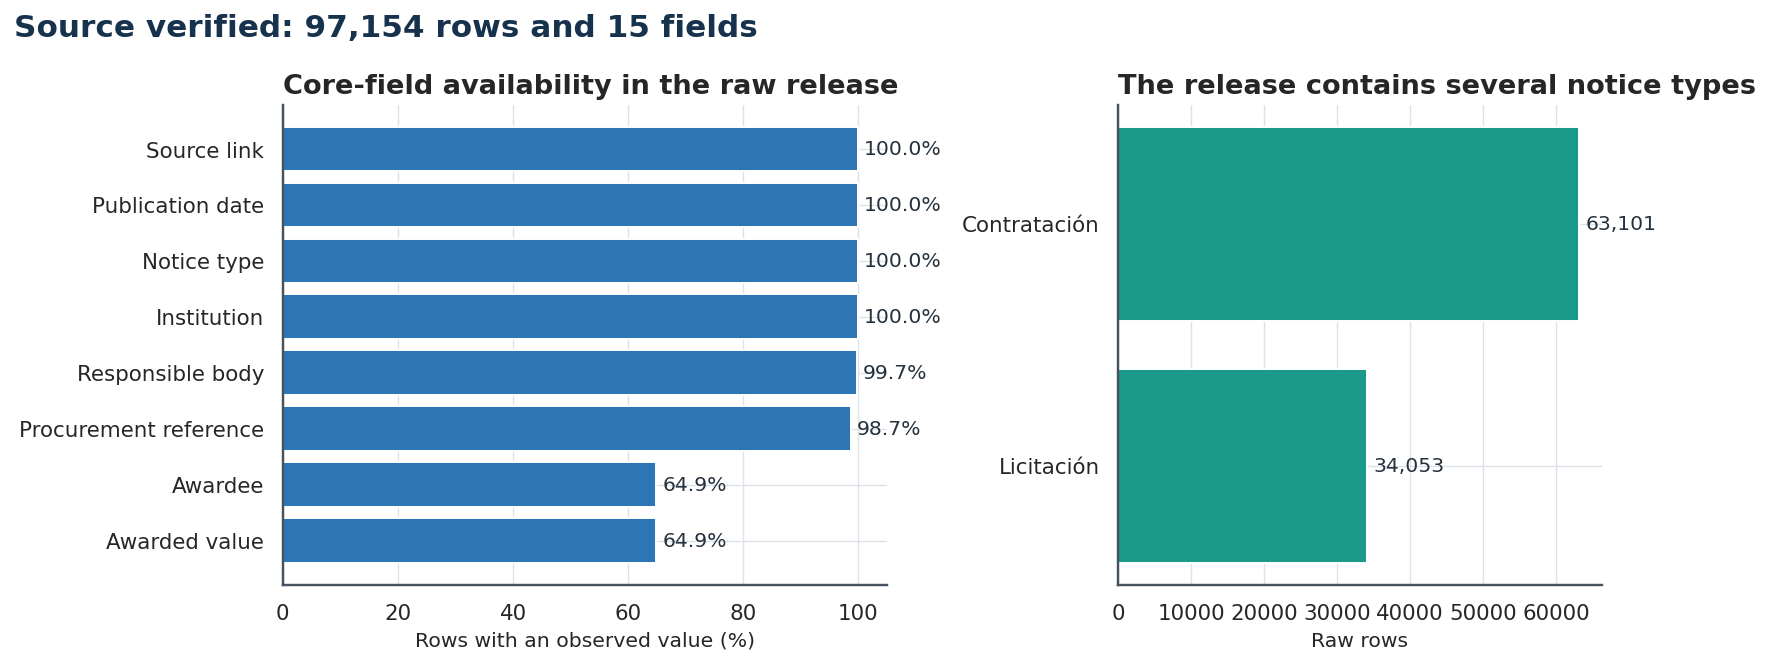

In [2]:
def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()

if not RAW.exists():
    raise FileNotFoundError(
        'The retained BOE source is missing. Download the exact release recorded in docs/SOURCE_REGISTER.md.'
    )

raw_sha256 = sha256(RAW)
assert raw_sha256 == EXPECTED_RAW_SHA256, 'The BOE file differs from the recorded release.'

raw = pd.read_csv(RAW, encoding='utf-8-sig', dtype=str, keep_default_na=False)

core_fields = {
    'Publication date': 'Fecha',
    'Notice type': 'Tipo',
    'Procurement reference': 'Expediente',
    'Institution': 'Institucion',
    'Responsible body': 'Organismo responsable',
    'Awardee': 'nombre_adjudicatario',
    'Awarded value': 'valor_oferta_adjudicada',
    'Source link': 'Enlace HTML',
}

def observed_share(series: pd.Series) -> float:
    cleaned = series.astype(str).str.strip().str.lower()
    return float((~cleaned.isin({'', 'no disponible', 'nan'})).mean() * 100)

completeness = pd.Series(
    {label: observed_share(raw[column]) for label, column in core_fields.items()}
).sort_values()
notice_types = raw['Tipo'].replace('', 'Missing').value_counts().head(6).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={'width_ratios': [1.25, 1]})
axes[0].barh(completeness.index, completeness.values, color=BLUE)
axes[0].set_xlim(0, 105)
axes[0].set_xlabel('Rows with an observed value (%)')
axes[0].set_title('Core-field availability in the raw release', loc='left')
for y, value in enumerate(completeness.values):
    axes[0].text(value + 1, y, f'{value:.1f}%', va='center', color=DARK)

axes[1].barh(notice_types.index, notice_types.values, color=TEAL)
axes[1].set_xlabel('Raw rows')
axes[1].set_title('The release contains several notice types', loc='left')
for y, value in enumerate(notice_types.values):
    axes[1].text(value + notice_types.max() * 0.015, y, f'{value:,}', va='center', color=DARK)

fig.suptitle(
    f'Source verified: {len(raw):,} rows and {len(raw.columns)} fields',
    x=0.01,
    ha='left',
    fontsize=16,
    fontweight='bold',
    color=NAVY,
)
finish_figure(fig)


**Reader takeaway:** The retained release is suitable for the declared workflow because every row has a source link, publication date, notice type and institution. Awardee and awarded-value fields appear on 64.9% of raw rows because the release also contains tender notices; the next step therefore keeps contracting notices.


## 3. Convert the published fields

The source stores dates, euro amounts and procurement codes as text. The following functions make those transformations explicit before any row is filtered or scored.


In [3]:
def parse_euro(value: str) -> float | None:
    text = (value or '').lower().replace('euros', '').replace('EUR', '').replace(chr(8364), '').strip()
    text = text.replace('.', '').replace(',', '.')
    match = re.search(r'[-+]?\d+(?:\.\d+)?', text)
    return float(match.group()) if match else None


def first_cpv_code(value: str) -> str:
    match = re.search(r'\b(\d{8})\b', value or '')
    return match.group(1) if match else ''


CPV_GROUPS = {
    '03': 'Agricultural, farming, fishing and forestry products',
    '09': 'Petroleum, fuel, electricity and other energy sources',
    '14': 'Mining, basic metals and related products',
    '15': 'Food, beverages, tobacco and related products',
    '16': 'Agricultural machinery',
    '18': 'Clothing, footwear, luggage and accessories',
    '19': 'Leather, textiles, plastic and rubber materials',
    '22': 'Printed matter and related products',
    '24': 'Chemical products',
    '30': 'Office and computing equipment and supplies',
    '31': 'Electrical machinery, equipment and consumables',
    '32': 'Communication and telecommunications equipment',
    '33': 'Medical equipment, pharmaceuticals and personal care products',
    '34': 'Transport equipment and auxiliary products',
    '35': 'Security, fire-fighting, police and defence equipment',
    '37': 'Musical instruments, sports goods, games and toys',
    '38': 'Laboratory, optical and precision equipment',
    '39': 'Furniture, domestic appliances and cleaning products',
    '41': 'Collected and purified water',
    '42': 'Industrial machinery',
    '43': 'Mining, quarrying and construction machinery',
    '44': 'Construction structures and materials',
    '45': 'Construction work',
    '48': 'Software packages and information systems',
    '50': 'Repair and maintenance services',
    '51': 'Installation services',
    '55': 'Hotel, restaurant and retail services',
    '60': 'Transport services',
    '63': 'Supporting and auxiliary transport services',
    '64': 'Postal and telecommunications services',
    '65': 'Public utilities',
    '66': 'Financial and insurance services',
    '70': 'Real-estate services',
    '71': 'Architecture, construction, engineering and inspection services',
    '72': 'IT services',
    '73': 'Research and development services',
    '75': 'Administration, defence and social security services',
    '76': 'Services related to the oil and gas industry',
    '77': 'Agricultural, forestry and related services',
    '79': 'Business services',
    '80': 'Education and training services',
    '85': 'Health and social work services',
    '90': 'Sewage, refuse, cleaning and environmental services',
    '92': 'Recreational, cultural and sporting services',
    '98': 'Other community, social and personal services',
}


def cpv_group(code: str) -> str:
    return CPV_GROUPS.get((code or '')[:2], 'Other procurement category')


def normalise_entity_name(value: str) -> str:
    text = unicodedata.normalize('NFKD', value or '')
    text = ''.join(character for character in text if not unicodedata.combining(character))
    text = text.upper().replace('&', ' Y ')
    return re.sub(r'[^A-Z0-9]+', '', text)


def source_notice_id(url: str) -> str:
    match = re.search(r'[?&]id=([^&]+)', url or '')
    return match.group(1) if match else (url or '').strip()


## 4. Apply the declared cleaning rule

The analytical population keeps awarded contracting notices published from 2022 through 2024 with a named awardee, a readable awarded value and one row per source notice.


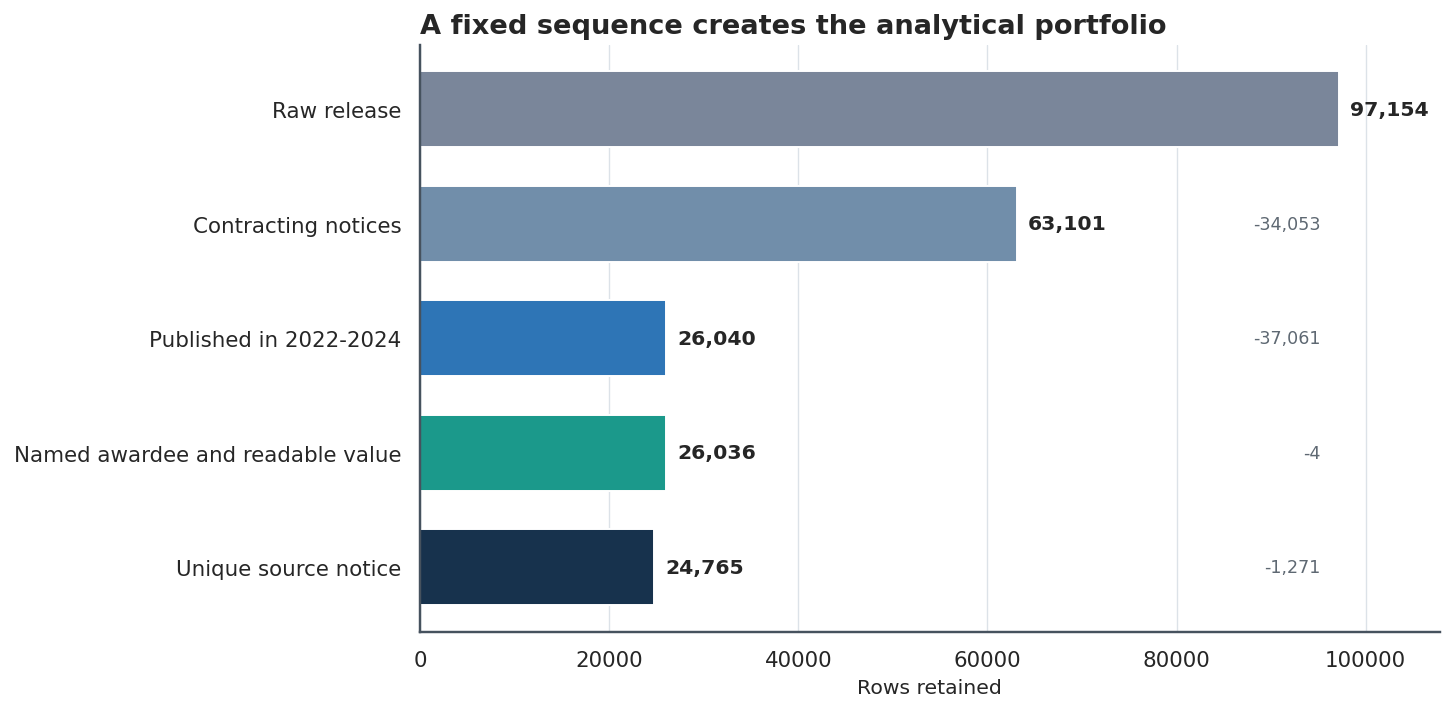

In [4]:
working = raw.copy()
working['publication_date'] = pd.to_datetime(working['Fecha'], dayfirst=True, errors='coerce')
working['contract_value_eur'] = working['valor_oferta_adjudicada'].map(parse_euro)
working['awardee_name_source'] = working['nombre_adjudicatario'].str.strip()

contracting_mask = working['Tipo'].eq('Contratación')
period_mask = working['publication_date'].between(START_DATE, END_DATE)
named_awardee_mask = (
    working['awardee_name_source'].ne('')
    & working['awardee_name_source'].str.lower().ne('no disponible')
)
readable_value_mask = working['contract_value_eur'].notna()

contracting = working.loc[contracting_mask].copy()
in_period = working.loc[contracting_mask & period_mask].copy()
complete = working.loc[
    contracting_mask & period_mask & named_awardee_mask & readable_value_mask
].copy()
repeated_parser_rows = complete.duplicated('Enlace HTML', keep='first')
eligible = complete.loc[~repeated_parser_rows].copy()

funnel = pd.DataFrame({
    'stage': [
        'Raw release',
        'Contracting notices',
        'Published in 2022-2024',
        'Named awardee and readable value',
        'Unique source notice',
    ],
    'rows': [len(working), len(contracting), len(in_period), len(complete), len(eligible)],
})
funnel['removed_from_previous'] = funnel['rows'].shift(1) - funnel['rows']

fig, ax = plt.subplots(figsize=(10.5, 5.2))
colours = [GREY, '#718EAA', BLUE, TEAL, NAVY]
y = np.arange(len(funnel))
ax.barh(y, funnel['rows'], color=colours, height=0.66)
ax.set_yticks(y, funnel['stage'])
ax.invert_yaxis()
ax.set_xlabel('Rows retained')
ax.set_title('A fixed sequence creates the analytical portfolio', loc='left')
ax.grid(axis='y', visible=False)
for index, row in funnel.iterrows():
    ax.text(row['rows'] + funnel['rows'].max() * 0.012, index, f"{row['rows']:,}", va='center', fontweight='bold')
    if index > 0:
        ax.text(
            funnel['rows'].max() * 0.98,
            index,
            f"-{int(row['removed_from_previous']):,}",
            va='center',
            ha='right',
            color='#5E6872',
            fontsize=9,
        )
ax.set_xlim(0, funnel['rows'].max() * 1.11)
finish_figure(fig)


**Reader takeaway:** The fixed rules reduce 97,154 raw rows to 24,765 unique, source-linked notices. Most exclusions come from removing tender notices and dates outside 2022-2024; only four in-scope contracting rows lack a usable awardee or value, and 1,271 repeated parser rows are removed at the final step.


## 5. Build a traceable procurement portfolio

Each retained row keeps its published source link and original fields. A display identifier is added for charts so a real awardee is not shown as objectively risky. The source field `Institucion` defines the grouping level used in the score; the more specific `Organismo responsable` remains available as a separate field.


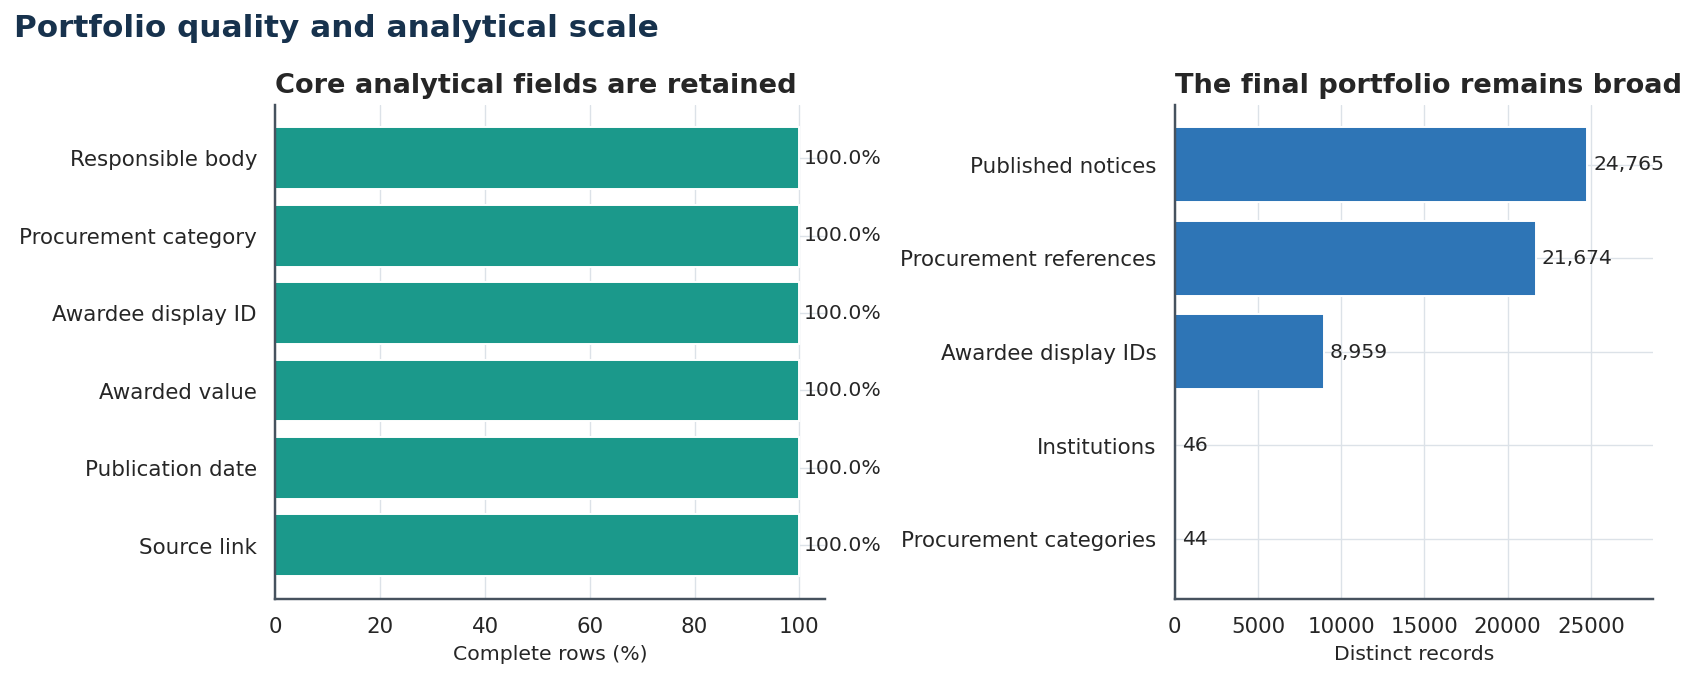

In [5]:
portfolio = pd.DataFrame({
    'source_notice_id': eligible['Enlace HTML'].map(source_notice_id),
    'contract_id': eligible['Expediente'],
    'notice_type': eligible['Tipo'],
    'contracting_authority_name': eligible['Institucion'],
    'responsible_body': eligible['Organismo responsable'],
    'contracting_authority_region': eligible['Ambito_geografico'],
    'awardee_name_source': eligible['awardee_name_source'],
    'publication_date': eligible['publication_date'],
    'contract_value_eur': eligible['contract_value_eur'],
    'cpv_code': eligible.apply(
        lambda row: first_cpv_code(row['Codigos_CPV']) or first_cpv_code(row['Materias_CPV']),
        axis=1,
    ),
    'cpv_description': eligible['Materias_CPV'],
    'contract_type': eligible['Naturaleza'],
    'procurement_procedure': eligible['Procedimiento'],
    'object_description': eligible['Objeto'],
    'source_url': eligible['Enlace HTML'],
})
portfolio.insert(0, 'exposure_id', [f'BOE-{number:05d}' for number in range(1, len(portfolio) + 1)])
portfolio['awardee_entity_key'] = portfolio['awardee_name_source'].map(normalise_entity_name)
portfolio['sector_group'] = portfolio['cpv_code'].map(cpv_group)

awardee_ids = {
    name: f'A{number:04d}'
    for number, name in enumerate(sorted(portfolio['awardee_entity_key'].unique()), start=1)
}
portfolio['awardee_display_id'] = portfolio['awardee_entity_key'].map(awardee_ids)
portfolio['awardee_contract_count'] = portfolio.groupby('awardee_entity_key')['exposure_id'].transform('size')

quality_fields = {
    'Source link': portfolio['source_url'].ne(''),
    'Publication date': portfolio['publication_date'].notna(),
    'Awarded value': portfolio['contract_value_eur'].notna(),
    'Awardee display ID': portfolio['awardee_display_id'].ne(''),
    'Procurement category': portfolio['sector_group'].ne('Other procurement category'),
    'Responsible body': portfolio['responsible_body'].astype(str).str.strip().ne(''),
}
portfolio_completeness = pd.Series({
    label: float(mask.mean() * 100) for label, mask in quality_fields.items()
}).sort_values()
portfolio_scale = pd.Series({
    'Published notices': len(portfolio),
    'Procurement references': portfolio['contract_id'].nunique(),
    'Awardee display IDs': portfolio['awardee_display_id'].nunique(),
    'Institutions': portfolio['contracting_authority_name'].nunique(),
    'Procurement categories': portfolio['sector_group'].nunique(),
}).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.9), gridspec_kw={'width_ratios': [1.15, 1]})
axes[0].barh(portfolio_completeness.index, portfolio_completeness.values, color=TEAL)
axes[0].set_xlim(0, 105)
axes[0].set_xlabel('Complete rows (%)')
axes[0].set_title('Core analytical fields are retained', loc='left')
for y, value in enumerate(portfolio_completeness.values):
    axes[0].text(value + 0.8, y, f'{value:.1f}%', va='center')

axes[1].barh(portfolio_scale.index, portfolio_scale.values, color=BLUE)
axes[1].set_xlabel('Distinct records')
axes[1].set_title('The final portfolio remains broad', loc='left')
for y, value in enumerate(portfolio_scale.values):
    axes[1].text(value + portfolio_scale.max() * 0.015, y, f'{int(value):,}', va='center')
axes[1].set_xlim(0, portfolio_scale.max() * 1.16)

fig.suptitle('Portfolio quality and analytical scale', x=0.01, ha='left', fontsize=16, fontweight='bold', color=NAVY)
finish_figure(fig)


**Reader takeaway:** The final portfolio retains complete core analytical fields across 24,765 notices, 21,674 procurement references and 8,959 anonymised awardee IDs. The 46 values in the source field `Institucion` define the grouping level used by the relationship-concentration measures.


## 6. Describe where published procurement value appears

The category view shows the main composition of the selected portfolio before the review score is introduced.


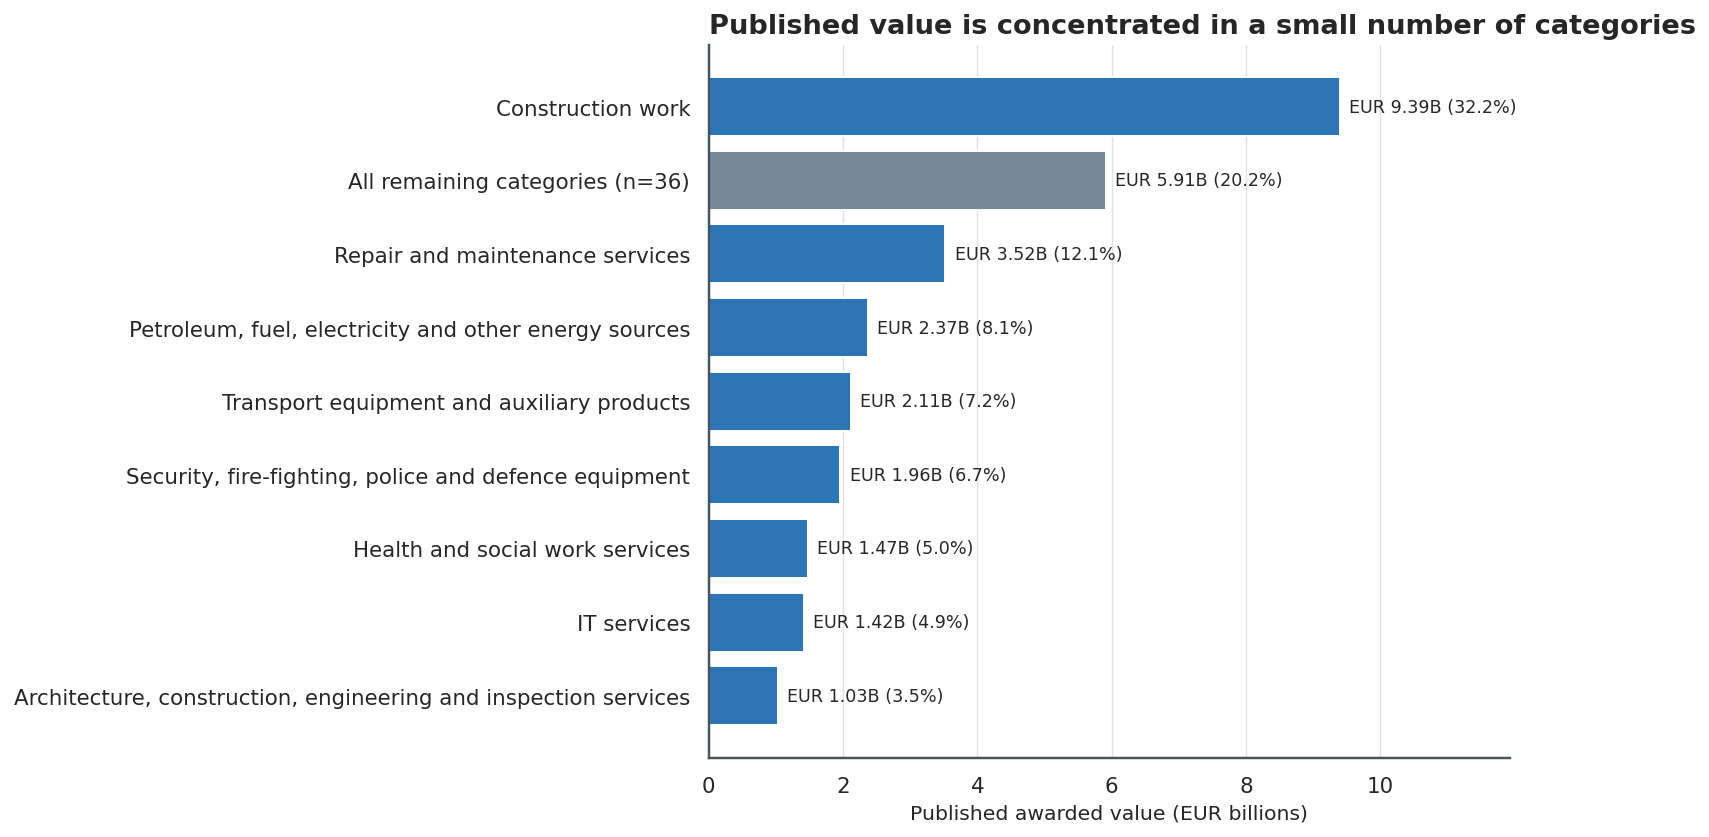

In [6]:
sector_summary = (
    portfolio.groupby('sector_group', as_index=False)
    .agg(
        notices=('exposure_id', 'count'),
        awardees=('awardee_display_id', 'nunique'),
        published_value_eur=('contract_value_eur', 'sum'),
    )
    .sort_values('published_value_eur', ascending=False)
)
sector_summary['value_share_pct'] = (
    sector_summary['published_value_eur'] / sector_summary['published_value_eur'].sum() * 100
)

top_categories = sector_summary.head(8).copy()
remaining = pd.DataFrame({
    'sector_group': [f'All remaining categories (n={max(len(sector_summary) - 8, 0)})'],
    'notices': [sector_summary.iloc[8:]['notices'].sum()],
    'awardees': [sector_summary.iloc[8:]['awardees'].sum()],
    'published_value_eur': [sector_summary.iloc[8:]['published_value_eur'].sum()],
    'value_share_pct': [sector_summary.iloc[8:]['value_share_pct'].sum()],
})
category_plot = pd.concat([top_categories, remaining], ignore_index=True)
category_plot = category_plot.sort_values('published_value_eur')

fig, ax = plt.subplots(figsize=(11, 6.1))
colours = [GREY if label.startswith('All remaining') else BLUE for label in category_plot['sector_group']]
ax.barh(category_plot['sector_group'], category_plot['published_value_eur'] / 1e9, color=colours)
ax.set_xlabel('Published awarded value (EUR billions)')
ax.set_title('Published value is concentrated in a small number of categories', loc='left')
ax.grid(axis='y', visible=False)
for y, (_, row) in enumerate(category_plot.iterrows()):
    ax.text(
        row['published_value_eur'] / 1e9 + category_plot['published_value_eur'].max() / 1e9 * 0.015,
        y,
        f"EUR {row['published_value_eur'] / 1e9:.2f}B ({row['value_share_pct']:.1f}%)",
        va='center',
        fontsize=9,
    )
ax.set_xlim(0, category_plot['published_value_eur'].max() / 1e9 * 1.27)
finish_figure(fig)


**Reader takeaway:** Construction work represents EUR 9.39 billion, or 32.2% of published value, while repair and maintenance services represent 12.1%. This concentration makes a category filter important when a reviewer wants to compare notices within a particular procurement area.


## 7. Check how published value changes over time

Monthly aggregation shows whether the observed portfolio is stable or dominated by a few publication peaks.


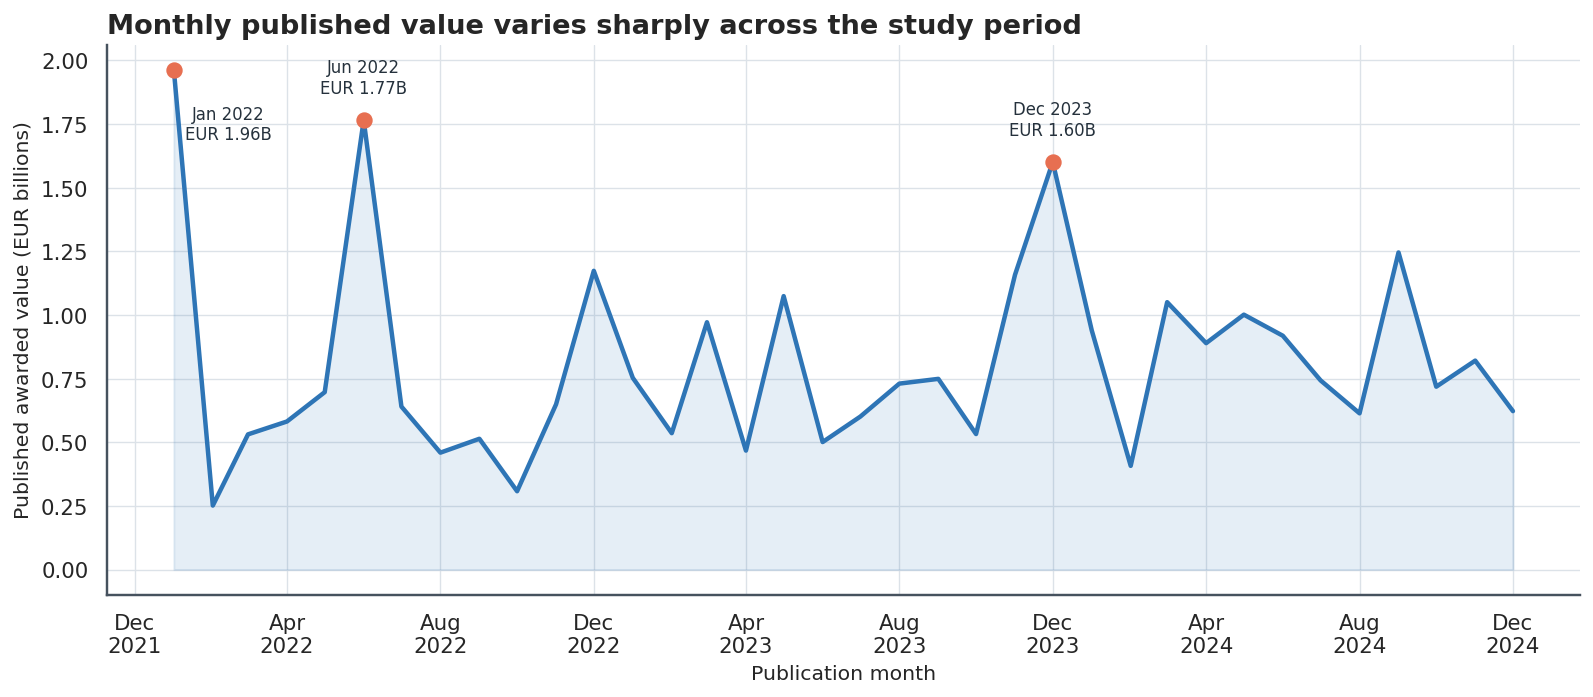

In [7]:
monthly = (
    portfolio.set_index('publication_date')
    .resample('MS')['contract_value_eur']
    .sum()
    .rename('published_value_eur')
    .reset_index()
)
peak_months = monthly.nlargest(3, 'published_value_eur')

fig, ax = plt.subplots(figsize=(11.5, 5.1))
ax.plot(monthly['publication_date'], monthly['published_value_eur'] / 1e9, color=BLUE, linewidth=2.3)
ax.fill_between(monthly['publication_date'], monthly['published_value_eur'] / 1e9, color=BLUE, alpha=0.12)
ax.scatter(peak_months['publication_date'], peak_months['published_value_eur'] / 1e9, color=ORANGE, s=55, zorder=3)
annotation_offsets = {
    pd.Timestamp('2022-01-01'): (28, -18),
    pd.Timestamp('2022-06-01'): (0, 12),
    pd.Timestamp('2023-12-01'): (0, 12),
}
for _, row in peak_months.iterrows():
    x_offset, y_offset = annotation_offsets.get(row['publication_date'], (0, 12))
    ax.annotate(
        f"{row['publication_date']:%b %Y}\nEUR {row['published_value_eur'] / 1e9:.2f}B",
        (row['publication_date'], row['published_value_eur'] / 1e9),
        xytext=(x_offset, y_offset),
        textcoords='offset points',
        ha='center',
        va='top' if y_offset < 0 else 'bottom',
        fontsize=8.5,
        color=DARK,
    )
ax.set_ylabel('Published awarded value (EUR billions)')
ax.set_xlabel('Publication month')
ax.set_title('Monthly published value varies sharply across the study period', loc='left')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
finish_figure(fig)


**Reader takeaway:** Published value varies substantially by month, with the largest peaks in January 2022 (EUR 1.96 billion), June 2022 (EUR 1.77 billion) and December 2023 (EUR 1.60 billion). These peaks describe publication timing and should not be read as effects of the external events introduced later.


## 8. Calculate the structural review score

The score orders notices inside this declared portfolio. It combines the notice-value percentile (50%), the awardee's value-share percentile within the source field `Institucion` (30%), and the awardee's notice-share percentile within the same institution (20%). It is an ordering rule, not a probability of disruption.


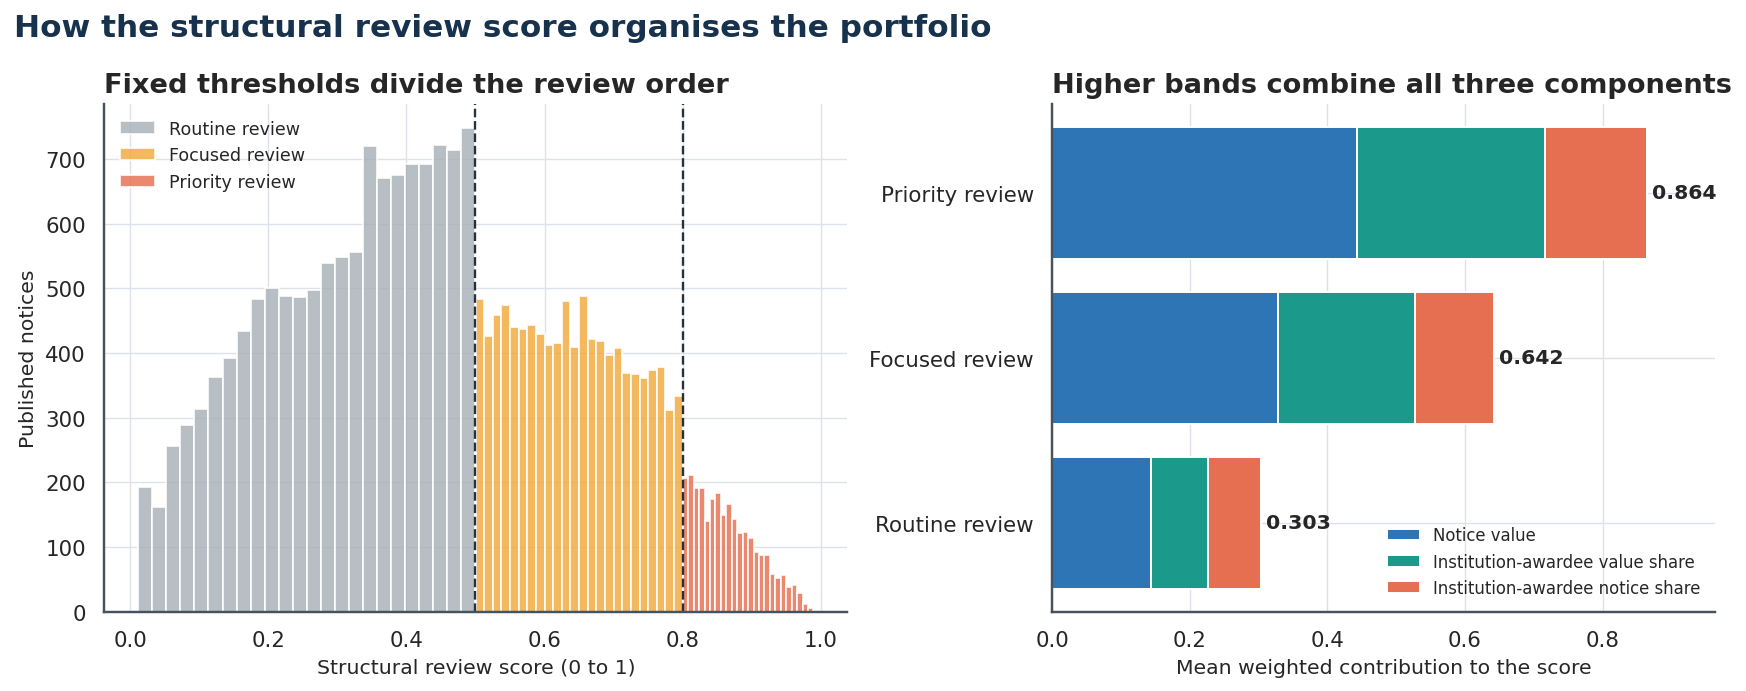

In [8]:
total_value = portfolio['contract_value_eur'].sum()
institution_total_value = portfolio.groupby('contracting_authority_name')['contract_value_eur'].transform('sum')
institution_awardee_value = portfolio.groupby(
    ['contracting_authority_name', 'awardee_display_id']
)['contract_value_eur'].transform('sum')
institution_notice_count = portfolio.groupby('contracting_authority_name')['exposure_id'].transform('size')
institution_awardee_notice_count = portfolio.groupby(
    ['contracting_authority_name', 'awardee_display_id']
)['exposure_id'].transform('size')

portfolio['awardee_portfolio_value_share'] = (
    portfolio.groupby('awardee_display_id')['contract_value_eur'].transform('sum') / total_value
).round(8)
portfolio['authority_awardee_value_share'] = (
    institution_awardee_value / institution_total_value
).round(8)
portfolio['authority_awardee_notice_share'] = (
    institution_awardee_notice_count / institution_notice_count
).round(8)
portfolio['sector_portfolio_value_share'] = (
    portfolio.groupby('sector_group')['contract_value_eur'].transform('sum') / total_value
).round(8)

def percentile(series: pd.Series) -> pd.Series:
    return series.rank(method='average', pct=True).fillna(0.0)

scored = portfolio.copy()
scored['value_percentile'] = percentile(scored['contract_value_eur'])
scored['authority_awardee_share_percentile'] = percentile(scored['authority_awardee_value_share'])
scored['authority_awardee_notice_share_percentile'] = percentile(scored['authority_awardee_notice_share'])
scored['value_contribution'] = 0.50 * scored['value_percentile']
scored['relationship_value_contribution'] = 0.30 * scored['authority_awardee_share_percentile']
scored['relationship_notice_contribution'] = 0.20 * scored['authority_awardee_notice_share_percentile']
scored['review_priority_score'] = (
    scored['value_contribution']
    + scored['relationship_value_contribution']
    + scored['relationship_notice_contribution']
).round(6)
scored['review_priority_band'] = pd.cut(
    scored['review_priority_score'],
    bins=[-0.01, 0.50, 0.80, 1.00],
    labels=REVIEW_BANDS,
)
scored['score_definition'] = (
    '0.50 contract-value percentile + 0.30 authority-awardee value-share percentile '
    '+ 0.20 authority-awardee notice-share percentile'
)

band_summary = (
    scored.groupby('review_priority_band', observed=False)
    .agg(notices=('exposure_id', 'count'), published_value_eur=('contract_value_eur', 'sum'))
    .reindex(REVIEW_BANDS)
)
band_summary['row_share_pct'] = band_summary['notices'] / len(scored) * 100
band_summary['value_share_pct'] = band_summary['published_value_eur'] / total_value * 100

contribution_means = (
    scored.groupby('review_priority_band', observed=False)[
        ['value_contribution', 'relationship_value_contribution', 'relationship_notice_contribution']
    ]
    .mean()
    .reindex(REVIEW_BANDS)
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), gridspec_kw={'width_ratios': [1.12, 1]})

for band in REVIEW_BANDS:
    values = scored.loc[scored['review_priority_band'].eq(band), 'review_priority_score']
    axes[0].hist(values, bins=24, alpha=0.82, color=BAND_COLOURS[band], label=band)
axes[0].axvline(0.50, color=DARK, linestyle='--', linewidth=1.2)
axes[0].axvline(0.80, color=DARK, linestyle='--', linewidth=1.2)
axes[0].set_xlabel('Structural review score (0 to 1)')
axes[0].set_ylabel('Published notices')
axes[0].set_title('Fixed thresholds divide the review order', loc='left')
axes[0].legend(frameon=False, fontsize=9)

left = np.zeros(len(REVIEW_BANDS))
contribution_specs = [
    ('value_contribution', 'Notice value', BLUE),
    ('relationship_value_contribution', 'Institution-awardee value share', TEAL),
    ('relationship_notice_contribution', 'Institution-awardee notice share', ORANGE),
]
for column, label, colour in contribution_specs:
    values = contribution_means[column].to_numpy()
    axes[1].barh(REVIEW_BANDS, values, left=left, color=colour, label=label)
    left += values
axes[1].set_xlabel('Mean weighted contribution to the score')
axes[1].set_title('Higher bands combine all three components', loc='left')
axes[1].legend(frameon=False, fontsize=8.5, loc='lower right')
for y, total in enumerate(left):
    axes[1].text(total + 0.008, y, f'{total:.3f}', va='center', fontweight='bold')
axes[1].set_xlim(0, min(1.0, left.max() + 0.1))

fig.suptitle('How the structural review score organises the portfolio', x=0.01, ha='left', fontsize=16, fontweight='bold', color=NAVY)
finish_figure(fig)


**Reader takeaway:** The fixed thresholds place 2,683 notices (10.8%) in the Priority review band, and these notices account for 69.5% of published value. Their mean score is 0.864, with visible contributions from notice value and both institution-awardee concentration measures.


## 9. Explain why the first notices appear at the top

The next chart separates the three weighted contributions for the first 15 notices instead of showing a long ranking table.


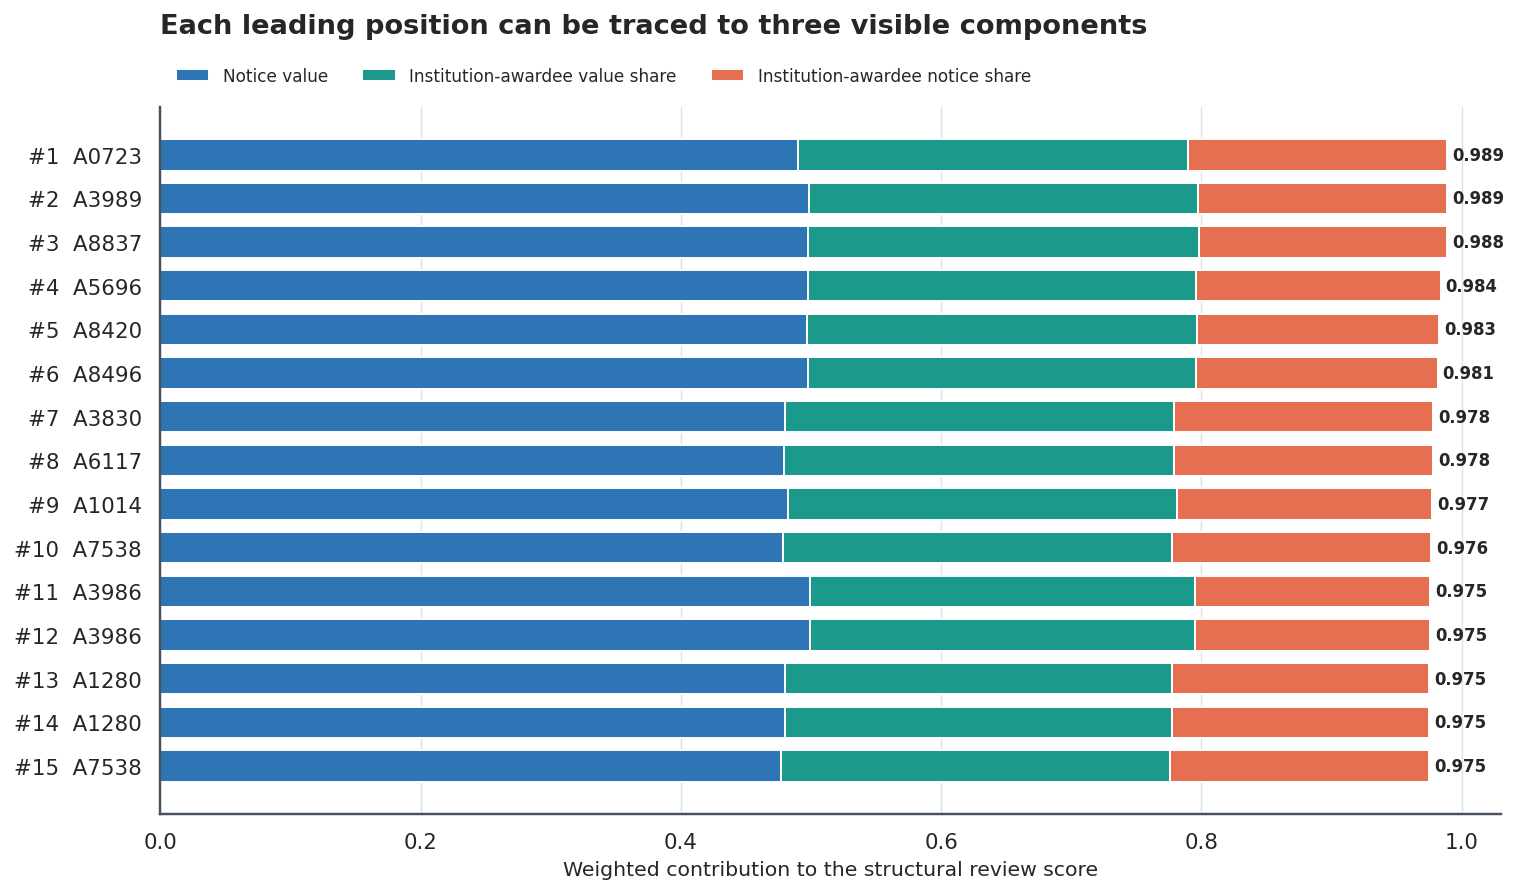

In [9]:
top_15 = scored.nlargest(15, 'review_priority_score').sort_values('review_priority_score')
top_labels = [
    f"#{rank}  {awardee}"
    for rank, awardee in zip(range(15, 0, -1), top_15['awardee_display_id'])
]

fig, ax = plt.subplots(figsize=(11, 6.5))
left = np.zeros(len(top_15))
for column, label, colour in contribution_specs:
    values = top_15[column].to_numpy()
    ax.barh(top_labels, values, left=left, color=colour, label=label, height=0.72)
    left += values
for y, total in enumerate(left):
    ax.text(total + 0.004, y, f'{total:.3f}', va='center', fontsize=8.5, fontweight='bold')
ax.set_xlim(0, 1.03)
ax.set_xlabel('Weighted contribution to the structural review score')
ax.set_title('Each leading position can be traced to three visible components', loc='left', pad=38)
ax.legend(frameon=False, ncol=3, loc='lower left', bbox_to_anchor=(0.0, 1.01), fontsize=8.7)
ax.grid(axis='y', visible=False)
finish_figure(fig)


**Reader takeaway:** The 15 leading scores range from 0.975 to 0.989, but their component mixtures are not identical. Showing the three contributions beside every total lets a reviewer understand why each notice reaches the top of the queue.


## 10. Compare priority-review prevalence across categories

This view checks whether the highest review band is concentrated in only one procurement area or appears across the portfolio.


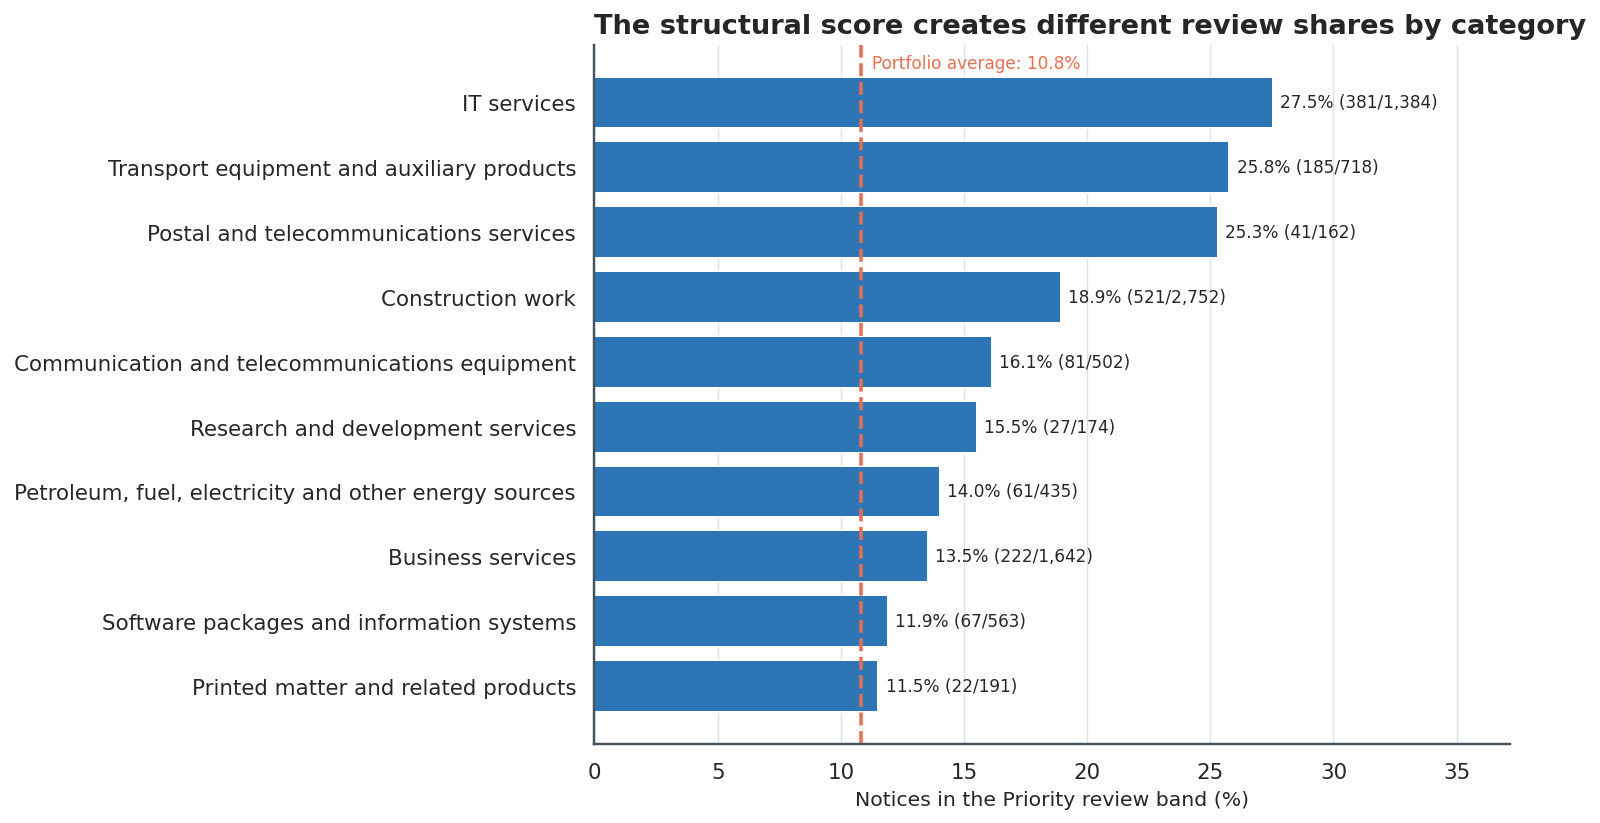

In [10]:
category_priority = (
    scored.assign(is_priority=scored['review_priority_band'].eq('Priority review'))
    .groupby('sector_group', as_index=False)
    .agg(notices=('exposure_id', 'count'), priority_notices=('is_priority', 'sum'))
)
category_priority['priority_share_pct'] = (
    category_priority['priority_notices'] / category_priority['notices'] * 100
)
category_priority = (
    category_priority.loc[category_priority['notices'].ge(100)]
    .nlargest(10, 'priority_share_pct')
    .sort_values('priority_share_pct')
)
overall_priority_share = scored['review_priority_band'].eq('Priority review').mean() * 100

fig, ax = plt.subplots(figsize=(11, 6.0))
ax.barh(category_priority['sector_group'], category_priority['priority_share_pct'], color=BLUE)
ax.axvline(overall_priority_share, color=ORANGE, linestyle='--', linewidth=1.8)
for y, (_, row) in enumerate(category_priority.iterrows()):
    ax.text(
        row['priority_share_pct'] + 0.3,
        y,
        f"{row['priority_share_pct']:.1f}% ({int(row['priority_notices']):,}/{int(row['notices']):,})",
        va='center',
        fontsize=8.7,
    )
ax.set_xlabel('Notices in the Priority review band (%)')
ax.set_title('The structural score creates different review shares by category', loc='left')
ax.text(
    overall_priority_share + 0.45,
    len(category_priority) - 0.25,
    f'Portfolio average: {overall_priority_share:.1f}%',
    color=ORANGE,
    fontsize=8.7,
    va='top',
)
ax.set_xlim(0, category_priority['priority_share_pct'].max() * 1.35)
ax.grid(axis='y', visible=False)
finish_figure(fig)


**Reader takeaway:** IT services has the largest Priority-band share at 27.5%, followed by transport equipment at 25.8%, compared with 10.8% for the portfolio. Category is not a direct score component, so these differences arise from the observed value and institution-awardee concentration of notices inside each category.


## 11. Reconcile the notebook with the retained dashboard data

These checks compare the notebook's calculations with the frozen files used by the dashboard. They stop execution if a key field differs.


In [11]:
frozen_portfolio = pd.read_csv(FROZEN_PORTFOLIO, parse_dates=['publication_date'])
frozen_scored = pd.read_csv(FROZEN_SCORED, parse_dates=['publication_date'])

portfolio_compare_columns = [
    'exposure_id', 'contract_id', 'awardee_display_id', 'contract_value_eur',
    'authority_awardee_value_share', 'authority_awardee_notice_share',
    'sector_portfolio_value_share', 'source_url',
]
score_compare_columns = [
    'exposure_id', 'value_percentile', 'authority_awardee_share_percentile',
    'authority_awardee_notice_share_percentile', 'review_priority_score',
    'review_priority_band',
]

observed_portfolio = portfolio[
    ['exposure_id', 'contract_id', 'awardee_display_id', 'contract_value_eur',
     'authority_awardee_value_share', 'authority_awardee_notice_share',
     'sector_portfolio_value_share', 'source_url']
].sort_values('exposure_id').reset_index(drop=True)
expected_portfolio = frozen_portfolio[portfolio_compare_columns].sort_values('exposure_id').reset_index(drop=True)
pd.testing.assert_frame_equal(observed_portfolio, expected_portfolio, check_dtype=False, atol=1e-8)

observed_score = scored[score_compare_columns].sort_values('exposure_id').reset_index(drop=True)
expected_score = frozen_scored[score_compare_columns].sort_values('exposure_id').reset_index(drop=True)
observed_score['review_priority_band'] = observed_score['review_priority_band'].astype(str)
expected_score['review_priority_band'] = expected_score['review_priority_band'].astype(str)
pd.testing.assert_frame_equal(observed_score, expected_score, check_dtype=False, atol=1e-8)

display(HTML(
    "<div style='border-left:5px solid #1B998B;padding:12px 16px;background:#F2FAF8;'>"
    "<b>Reconciliation passed.</b> The notebook recreated all 24,765 portfolio rows, "
    "the three score components, the final score and every review band used by the dashboard."
    "</div>"
))


**Reader takeaway:** The notebook rebuild matches the frozen dashboard portfolio row for row and reproduces the same structural scores and bands. This check connects the documented transformations directly to the files used by the interface.


## 12. Load the official geopolitical event context

Four retained official records represent three documented campaigns: European Union sanctions, Panama Canal restrictions and Red Sea shipping security. Their dates and source links remain separate from the structural score.


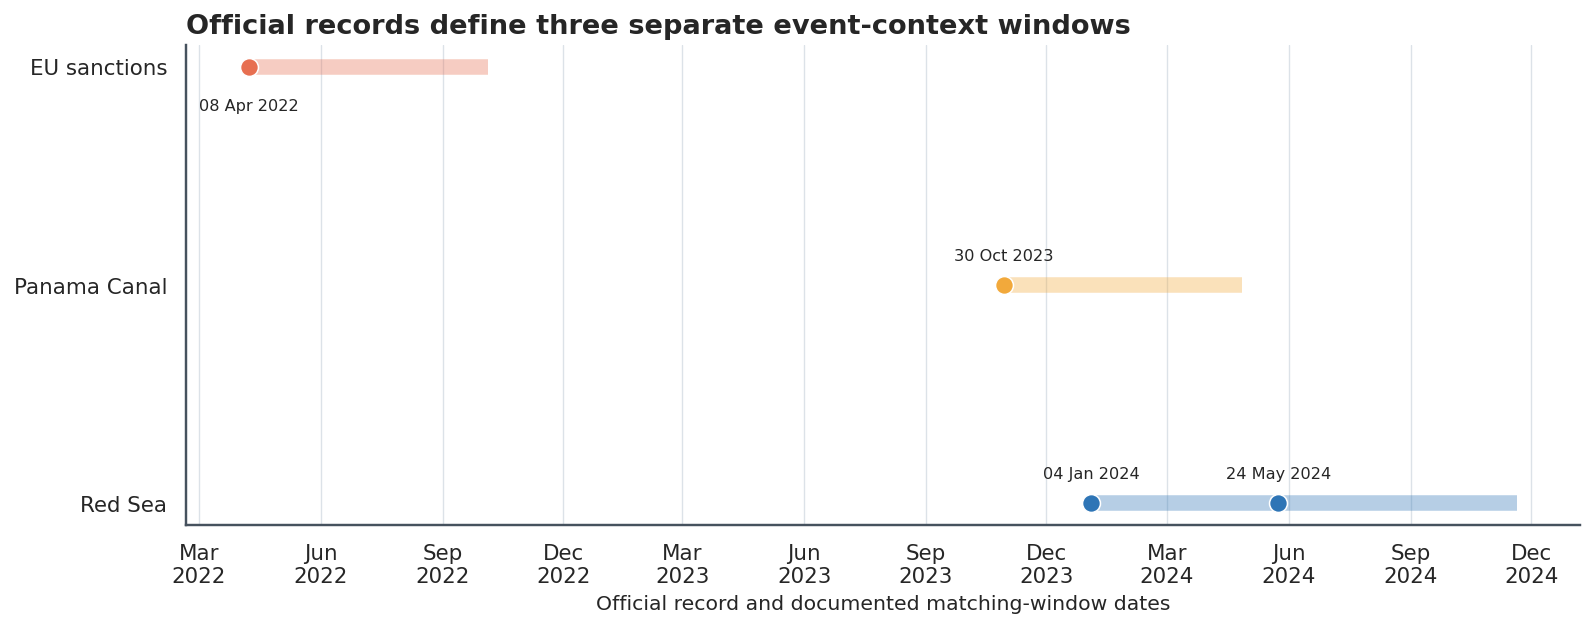

In [12]:
events = pd.read_csv(
    EVENTS,
    parse_dates=['published_date', 'campaign_start_date', 'campaign_end_date'],
)
campaign_labels = {
    'CAMPAIGN-EU-SANCTIONS-2022': 'EU sanctions',
    'CAMPAIGN-PANAMA-2023': 'Panama Canal',
    'CAMPAIGN-RED-SEA-2024': 'Red Sea',
}
family_colours = {
    'sanctions/trade policy': ORANGE,
    'logistics/transport': AMBER,
    'conflict/security': BLUE,
}

campaign_order = list(campaign_labels)
fig, ax = plt.subplots(figsize=(11.5, 4.6))
for y, campaign_id in enumerate(campaign_order):
    campaign = events.loc[events['event_campaign_id'].eq(campaign_id)].sort_values('published_date')
    start = campaign['campaign_start_date'].min()
    end = campaign['campaign_end_date'].max()
    colour = family_colours[campaign.iloc[0]['event_family']]
    ax.hlines(y, start, end, color=colour, linewidth=8, alpha=0.35)
    ax.scatter(campaign['published_date'], [y] * len(campaign), color=colour, s=85, zorder=3, edgecolor='white', linewidth=0.8)
    for _, row in campaign.iterrows():
        y_offset = -16 if campaign_id == 'CAMPAIGN-EU-SANCTIONS-2022' else 11
        ax.annotate(
            f"{row['published_date']:%d %b %Y}",
            (row['published_date'], y),
            xytext=(0, y_offset),
            textcoords='offset points',
            ha='center',
            va='top' if y_offset < 0 else 'bottom',
            fontsize=8.3,
        )
ax.set_yticks(range(len(campaign_order)), [campaign_labels[item] for item in campaign_order])
ax.invert_yaxis()
ax.set_xlabel('Official record and documented matching-window dates')
ax.set_title('Official records define three separate event-context windows', loc='left')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.grid(axis='y', visible=False)
finish_figure(fig)


**Reader takeaway:** Four dated official records define three event-context windows: EU sanctions, the Panama Canal and the Red Sea. The record date and source are stored before any notice is matched, which keeps the external context traceable.


## 13. Match event context to procurement notices

The crosswalk applies date, broad geography and procurement-category rules fixed before matching. A match means that a notice should be checked beside an official event source; it does not confirm that the awardee used a particular country, port or route.


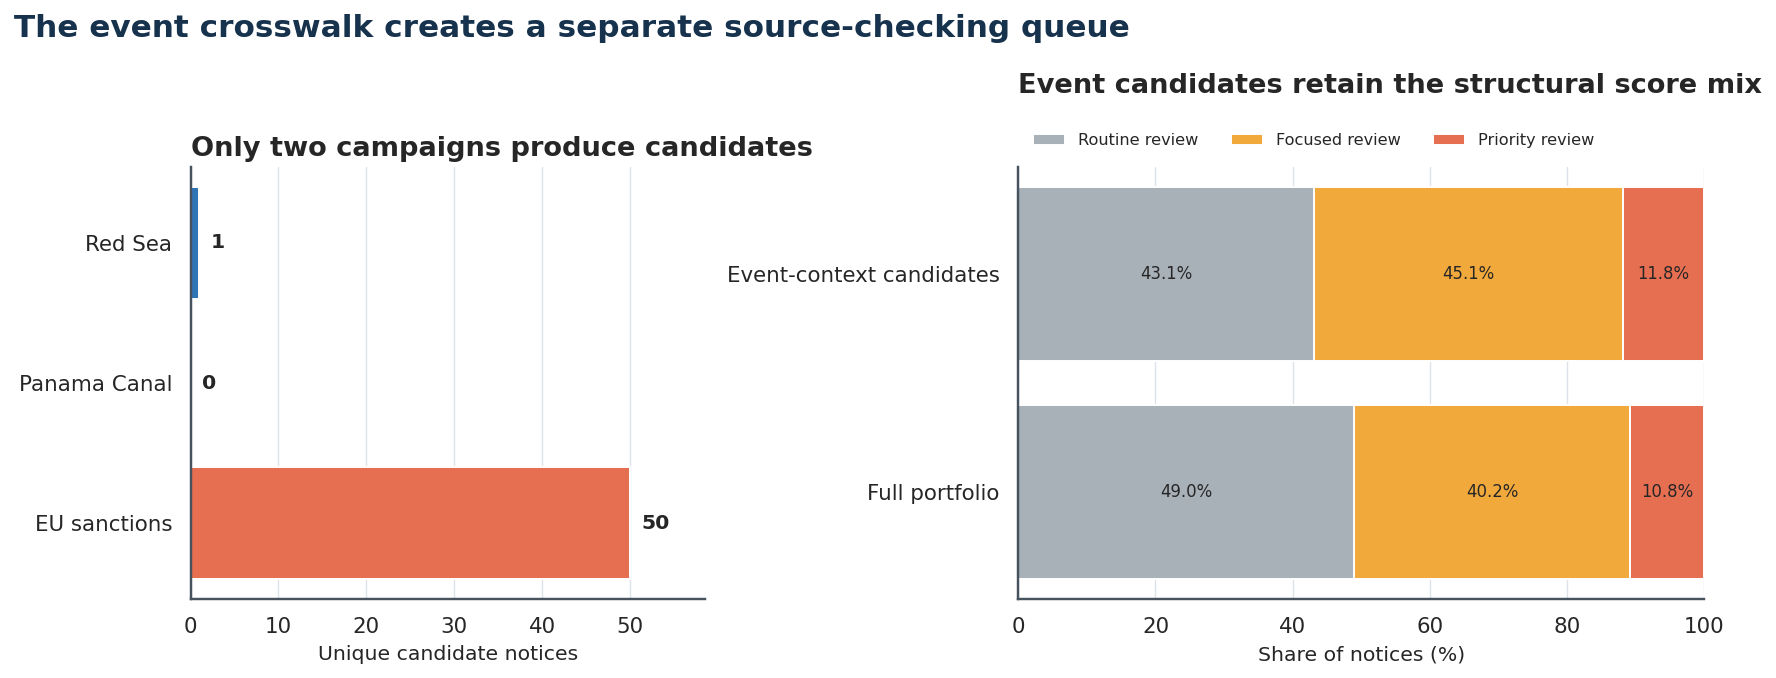

In [13]:
GEOGRAPHY_SCOPE = {
    'EVT-2022-001': 'national',
    'EVT-2023-001': 'international_only',
    'EVT-2024-001': 'international_only',
    'EVT-2024-002': 'international_only',
}
CATEGORY_RULES = {
    'EVT-2022-001': {
        'sector_groups': {'Petroleum, fuel, electricity and other energy sources'},
        'cpv_prefixes': set(),
    },
    'EVT-2023-001': {
        'sector_groups': {'Transport equipment and auxiliary products'},
        'cpv_prefixes': {'34', '60', '61', '62', '63', '64'},
    },
    'EVT-2024-001': {
        'sector_groups': {'Transport equipment and auxiliary products'},
        'cpv_prefixes': {'34', '60', '61', '62', '63', '64'},
    },
    'EVT-2024-002': {
        'sector_groups': {'Transport equipment and auxiliary products'},
        'cpv_prefixes': {'34', '60', '61', '62', '63', '64'},
    },
}

def geography_matches(region: str, scope: str) -> bool:
    if scope == 'national':
        return True
    return (region or '').strip() == 'Internacional'


def category_matches(sector_group: str, cpv_code: str, rule: dict) -> bool:
    cpv2 = (cpv_code or '').zfill(8)[:2]
    return sector_group in rule['sector_groups'] or cpv2 in rule['cpv_prefixes']


match_rows = []
for _, event in events.iterrows():
    geography_mask = scored['contracting_authority_region'].map(
        lambda value: geography_matches(value, GEOGRAPHY_SCOPE[event['event_id']])
    )
    category_mask = scored.apply(
        lambda row: category_matches(
            row['sector_group'], row['cpv_code'], CATEGORY_RULES[event['event_id']]
        ),
        axis=1,
    )
    date_mask = scored['publication_date'].between(
        event['campaign_start_date'], event['campaign_end_date']
    )
    for exposure_id in scored.loc[geography_mask & category_mask & date_mask, 'exposure_id']:
        match_rows.append({
            'event_id': event['event_id'],
            'event_campaign_id': event['event_campaign_id'],
            'exposure_id': exposure_id,
        })

matches = pd.DataFrame(match_rows)
candidate_ids = set(matches['exposure_id']) if len(matches) else set()
scored['candidate_event_context_flag'] = scored['exposure_id'].isin(candidate_ids)

campaign_counts = (
    matches.groupby('event_campaign_id')['exposure_id'].nunique()
    .reindex(campaign_order, fill_value=0)
)
comparison = pd.DataFrame({
    'Full portfolio': scored['review_priority_band'].value_counts(normalize=True).reindex(REVIEW_BANDS, fill_value=0),
    'Event-context candidates': scored.loc[
        scored['candidate_event_context_flag'], 'review_priority_band'
    ].value_counts(normalize=True).reindex(REVIEW_BANDS, fill_value=0),
}).T * 100

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9), gridspec_kw={'width_ratios': [0.9, 1.2]})
campaign_names = [campaign_labels[item] for item in campaign_order]
axes[0].barh(campaign_names, campaign_counts.values, color=[ORANGE, AMBER, BLUE])
axes[0].set_xlabel('Unique candidate notices')
axes[0].set_title('Only two campaigns produce candidates', loc='left')
axes[0].grid(axis='y', visible=False)
for y, value in enumerate(campaign_counts.values):
    axes[0].text(value + max(campaign_counts.max(), 1) * 0.025, y, f'{int(value)}', va='center', fontweight='bold')
axes[0].set_xlim(0, max(campaign_counts.max(), 1) * 1.17)

left = np.zeros(len(comparison))
for band in REVIEW_BANDS:
    values = comparison[band].to_numpy()
    axes[1].barh(comparison.index, values, left=left, color=BAND_COLOURS[band], label=band)
    for y, (start, value) in enumerate(zip(left, values)):
        if value >= 8:
            axes[1].text(start + value / 2, y, f'{value:.1f}%', ha='center', va='center', fontsize=8.5)
    left += values
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Share of notices (%)')
axes[1].set_title('Event candidates retain the structural score mix', loc='left', pad=38)
axes[1].legend(frameon=False, ncol=3, loc='lower left', bbox_to_anchor=(0.0, 1.01), fontsize=8.3)
axes[1].grid(axis='y', visible=False)

fig.suptitle('The event crosswalk creates a separate source-checking queue', x=0.01, ha='left', fontsize=16, fontweight='bold', color=NAVY)
finish_figure(fig)


**Reader takeaway:** The crosswalk identifies 51 unique candidate notices: 50 for the EU sanctions campaign, one for the Red Sea campaign and none for the Panama Canal campaign. Their structural band mix remains close to the full portfolio, confirming that event context forms a separate source-checking queue rather than changing the score.


## 14. Reconcile the event crosswalk

The recomputed event-notice pairs must match the frozen file used by the dashboard.


In [14]:
frozen_matches = pd.read_csv(FROZEN_MATCHES)
observed_pairs = set(zip(matches['event_id'], matches['exposure_id']))
expected_pairs = set(zip(frozen_matches['event_id'], frozen_matches['exposure_id']))
assert observed_pairs == expected_pairs, 'The recomputed event crosswalk differs from the dashboard file.'

display(HTML(
    "<div style='border-left:5px solid #1B998B;padding:12px 16px;background:#F2FAF8;'>"
    f"<b>Crosswalk reconciliation passed.</b> The notebook recreated {len(observed_pairs):,} event-notice pairs "
    f"covering {len(candidate_ids):,} unique candidate notices."
    "</div>"
))


**Reader takeaway:** The rebuilt crosswalk reproduces all 52 stored event-notice pairs, covering 51 unique notices. The extra pair occurs because one notice can match more than one dated record within the same campaign.


## 15. Test the two main design choices

Sensitivity analysis changes the score weights and the number of days retained after each campaign's latest official record. It shows how much the outputs depend on those choices; it does not optimise them.


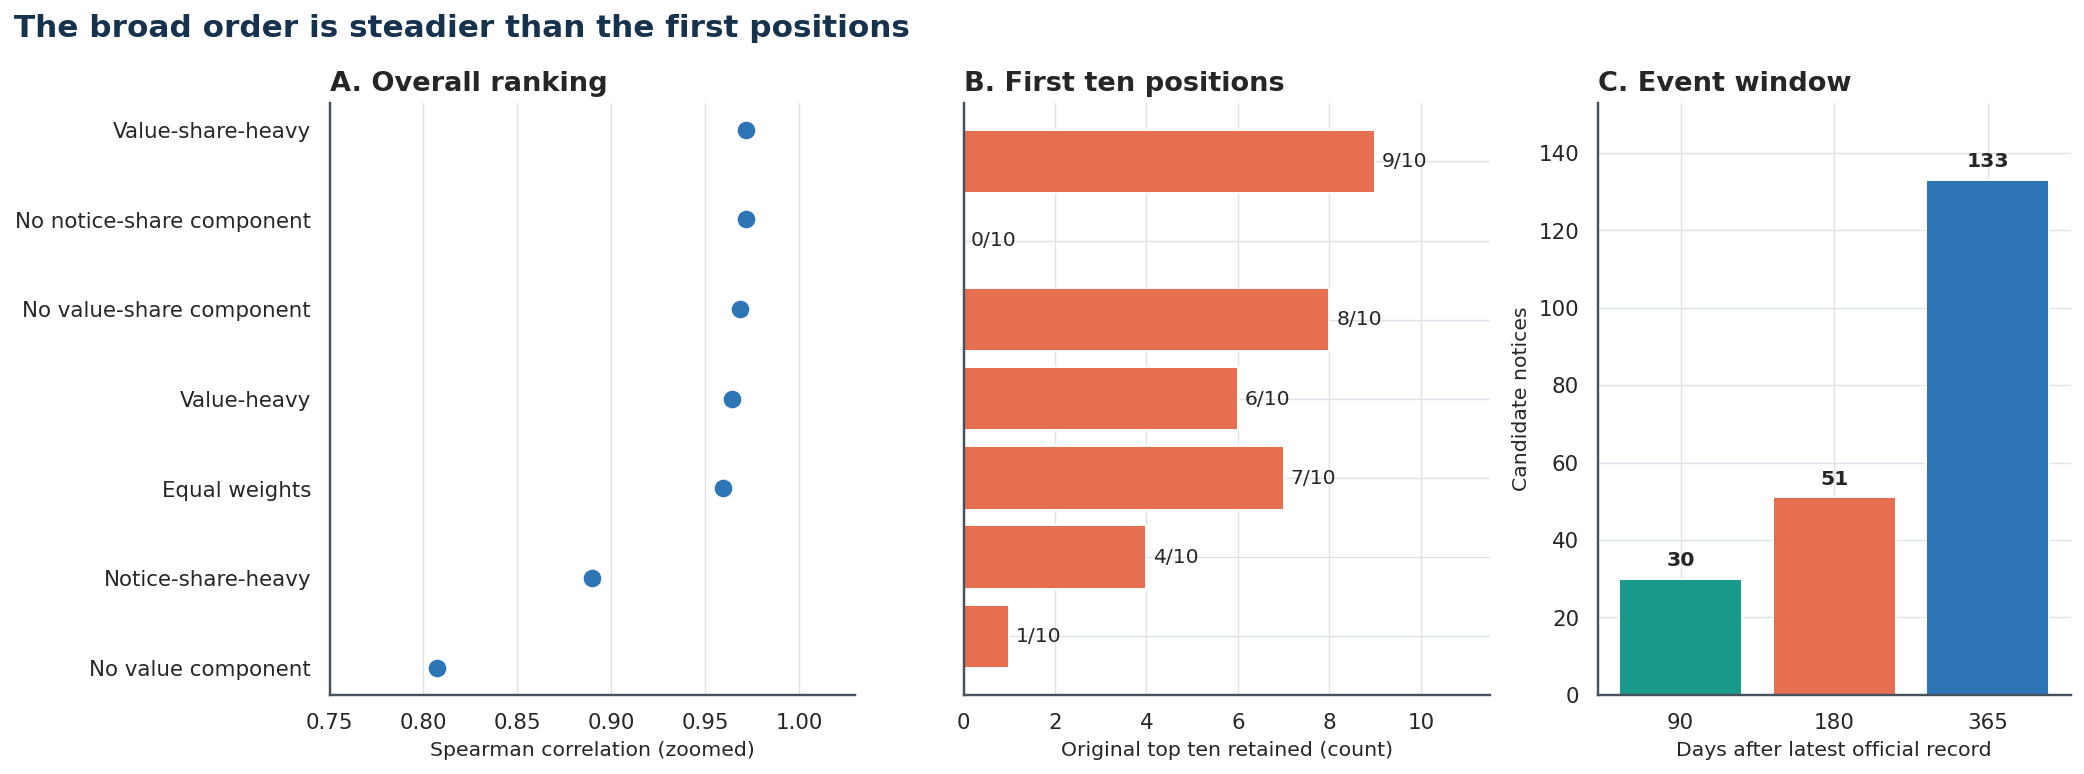

In [15]:
SCORE_SCENARIOS = {
    'Equal weights': (1 / 3, 1 / 3, 1 / 3),
    'Value-heavy': (0.70, 0.20, 0.10),
    'Value-share-heavy': (0.30, 0.50, 0.20),
    'Notice-share-heavy': (0.30, 0.20, 0.50),
    'No value component': (0.00, 0.60, 0.40),
    'No value-share component': (5 / 7, 0.00, 2 / 7),
    'No notice-share component': (0.625, 0.375, 0.00),
}
score_columns = [
    'value_percentile',
    'authority_awardee_share_percentile',
    'authority_awardee_notice_share_percentile',
]
baseline = scored['review_priority_score']
baseline_top_10 = set(scored.nlargest(10, 'review_priority_score')['exposure_id'])
baseline_top_100 = set(scored.nlargest(100, 'review_priority_score')['exposure_id'])

score_sensitivity_rows = []
for scenario, weights in SCORE_SCENARIOS.items():
    alternative = sum(
        weight * scored[column] for weight, column in zip(weights, score_columns)
    ).round(6)
    alternative_frame = scored.assign(alternative_score=alternative)
    top_10 = set(alternative_frame.nlargest(10, 'alternative_score')['exposure_id'])
    top_100 = set(alternative_frame.nlargest(100, 'alternative_score')['exposure_id'])
    score_sensitivity_rows.append({
        'scenario': scenario,
        'rank_correlation': alternative.rank(method='average').corr(baseline.rank(method='average')),
        'top_10_overlap_share': len(top_10 & baseline_top_10) / 10,
        'top_100_overlap_share': len(top_100 & baseline_top_100) / 100,
    })
score_sensitivity = pd.DataFrame(score_sensitivity_rows)

window_rows = []
for days in (90, 180, 365):
    all_candidate_ids = set()
    for campaign_id, campaign in events.groupby('event_campaign_id'):
        first_event = campaign.sort_values('published_date').iloc[0]
        event_id = first_event['event_id']
        start = campaign['published_date'].min()
        end = campaign['published_date'].max() + pd.Timedelta(days=days)
        geography_mask = scored['contracting_authority_region'].map(
            lambda value: geography_matches(value, GEOGRAPHY_SCOPE[event_id])
        )
        category_mask = scored.apply(
            lambda row: category_matches(
                row['sector_group'], row['cpv_code'], CATEGORY_RULES[event_id]
            ),
            axis=1,
        )
        ids = set(scored.loc[
            geography_mask & category_mask & scored['publication_date'].between(start, end),
            'exposure_id',
        ])
        all_candidate_ids.update(ids)
    window_rows.append({'window_days': days, 'candidate_notices': len(all_candidate_ids)})
window_sensitivity = pd.DataFrame(window_rows)

score_plot = score_sensitivity.sort_values('rank_correlation')
fig, axes = plt.subplots(1, 3, figsize=(15, 5.6), gridspec_kw={'width_ratios': [1, 1, 0.9]})
y = np.arange(len(score_plot))
axes[0].scatter(score_plot['rank_correlation'], y, color=BLUE, s=65, label='Rank correlation')
axes[0].set_yticks(y, score_plot['scenario'])
axes[0].set_xlim(0.75, 1.03)
axes[0].set_xlabel('Spearman correlation (zoomed)')
axes[0].set_title('A. Overall ranking', loc='left')
axes[0].grid(axis='y', visible=False)
retained = (score_plot['top_10_overlap_share'] * 10).round().astype(int)
axes[1].barh(y, retained, color=ORANGE)
axes[1].set_yticks(y, [''] * len(y))
axes[1].set_xlim(0, 11.5)
axes[1].set_xlabel('Original top ten retained (count)')
axes[1].set_title('B. First ten positions', loc='left')
for row, value in enumerate(retained):
    axes[1].text(value + 0.15, row, f'{value}/10', va='center')

axes[2].bar(window_sensitivity['window_days'].astype(str), window_sensitivity['candidate_notices'], color=[TEAL, ORANGE, BLUE])
axes[2].set_xlabel('Days after latest official record')
axes[2].set_ylabel('Candidate notices')
axes[2].set_title('C. Event window', loc='left')
for x, value in enumerate(window_sensitivity['candidate_notices']):
    axes[2].text(x, value + window_sensitivity['candidate_notices'].max() * 0.025, f'{int(value)}', ha='center', fontweight='bold')
axes[2].set_ylim(0, window_sensitivity['candidate_notices'].max() * 1.15)

fig.suptitle('The broad order is steadier than the first positions', x=0.01, ha='left', fontsize=16, fontweight='bold', color=NAVY)
finish_figure(fig)


**Reader takeaway:** Alternative score weights preserve the broad ordering more strongly than the first ten positions, so the weights remain a visible design choice. Expanding the event window from 90 to 180 and 365 days increases the candidate queue from 30 to 51 and 133 notices.


## 16. Inspect the local-model development exercise

The local `openai/gpt-oss-20b` model assigns one of three prepared event families to 14 selected official records. Set `RUN_LOCAL_MODEL = True` only when LM Studio is running locally and the model is loaded; otherwise this cell reads the retained result.


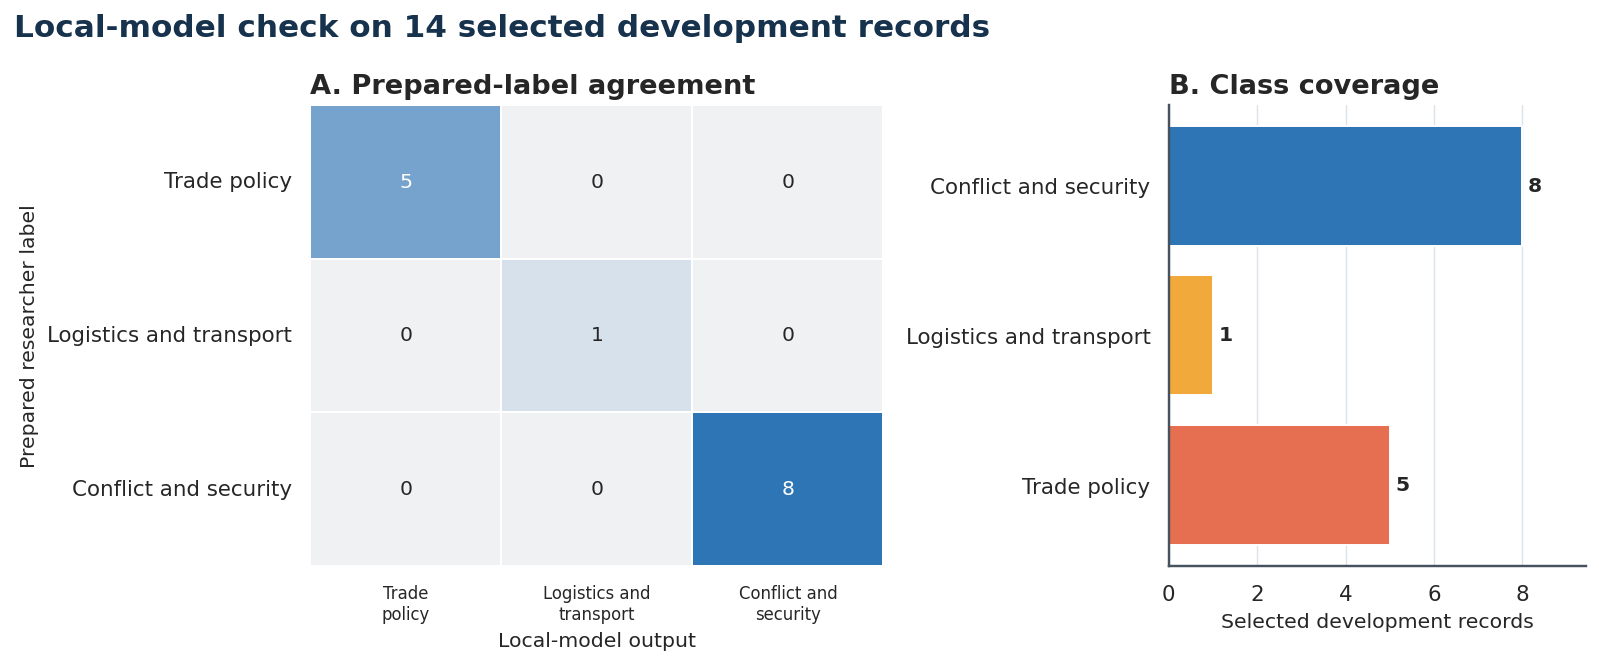

In [16]:
RUN_LOCAL_MODEL = False
if RUN_LOCAL_MODEL:
    subprocess.run([sys.executable, str(ROOT / 'src' / 'evaluate_local_llm.py')], cwd=ROOT, check=True)

local_result = pd.read_csv(LOCAL_MODEL_RESULT)
class_order = ['trade_policy', 'logistics_transport', 'conflict_security']
class_labels = ['Trade policy', 'Logistics and transport', 'Conflict and security']
class_tick_labels = ['Trade\npolicy', 'Logistics and\ntransport', 'Conflict and\nsecurity']
confusion = pd.crosstab(
    local_result['label_event_family'],
    local_result['local_llm_prediction'],
).reindex(index=class_order, columns=class_order, fill_value=0)
class_coverage = local_result['label_event_family'].value_counts().reindex(class_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), gridspec_kw={'width_ratios': [1.1, 0.8]})
sns.heatmap(
    confusion,
    annot=True,
    fmt='g',
    cmap=sns.light_palette(BLUE, as_cmap=True),
    cbar=False,
    linewidths=1,
    linecolor='white',
    ax=axes[0],
)
axes[0].set_xticklabels(class_tick_labels, rotation=0, fontsize=8.5)
axes[0].set_yticklabels(class_labels, rotation=0)
axes[0].set_xlabel('Local-model output')
axes[0].set_ylabel('Prepared researcher label')
axes[0].set_title('A. Prepared-label agreement', loc='left')

axes[1].barh(class_labels, class_coverage.values, color=[ORANGE, AMBER, BLUE])
axes[1].set_xlabel('Selected development records')
axes[1].set_title('B. Class coverage', loc='left')
for y, value in enumerate(class_coverage.values):
    axes[1].text(value + 0.12, y, str(int(value)), va='center', fontweight='bold')
axes[1].set_xlim(0, max(class_coverage.max(), 1) * 1.18)
axes[1].grid(axis='y', visible=False)

fig.suptitle('Local-model check on 14 selected development records', x=0.01, ha='left', fontsize=16, fontweight='bold', color=NAVY)
finish_figure(fig)


**Reader takeaway:** The local model agrees with the prepared labels for all 14 selected development records, but class coverage is uneven: eight conflict and security, five trade policy and one logistics record. This checks the event-family definitions and output format; it is not used as a performance estimate on new records.


## 17. Review the optional live-discovery snapshot

Five keyed search providers collect recent candidate reports, while GDELT is checked separately at low volume. The local model assigns a family to the saved candidates. Set `RUN_LIVE_REFRESH = True` only when private credentials are available; the frozen thesis results never depend on this optional refresh.


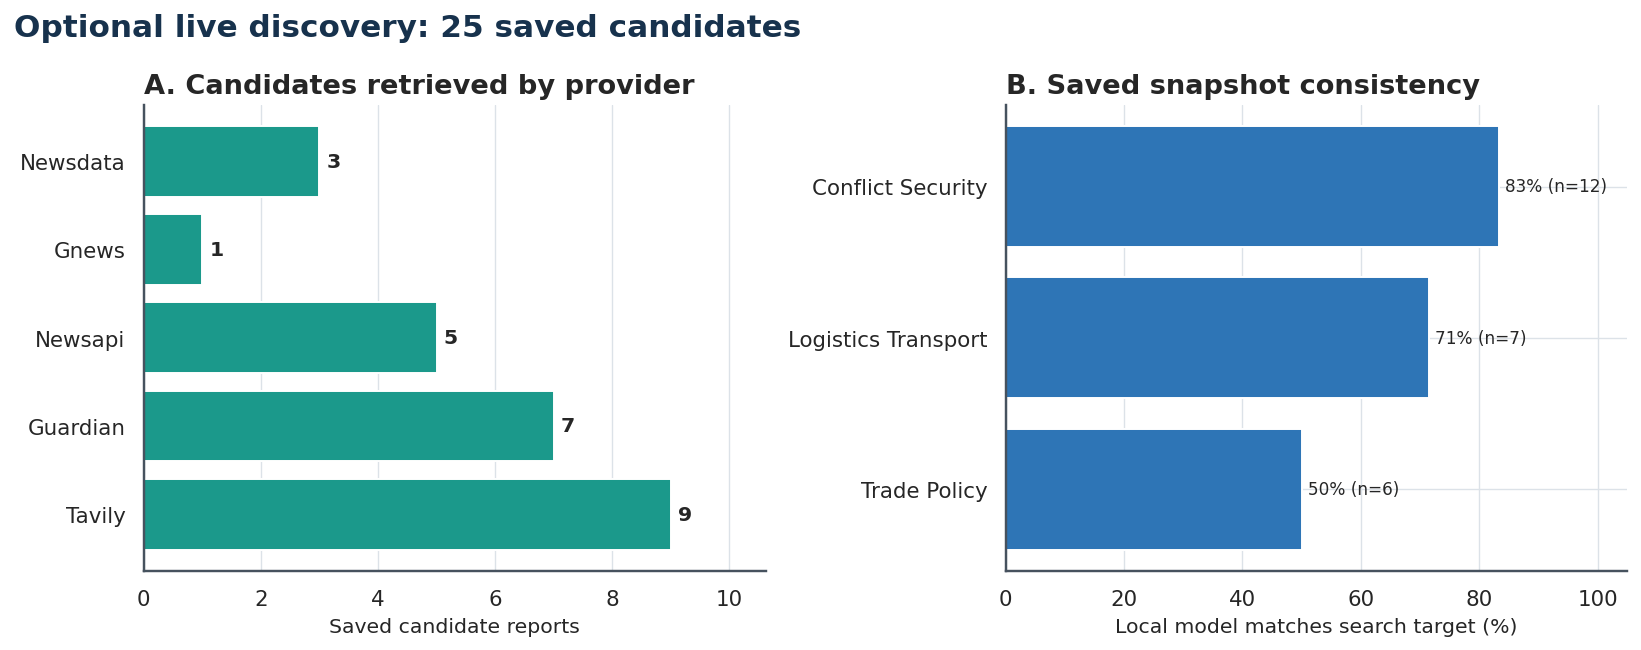

In [17]:
RUN_LIVE_REFRESH = False
if RUN_LIVE_REFRESH:
    subprocess.run([sys.executable, str(ROOT / 'src' / 'check_live_services.py')], cwd=ROOT, check=True)
    subprocess.run([sys.executable, str(ROOT / 'src' / 'live_evidence_discovery.py')], cwd=ROOT, check=True)

snapshots = sorted(LIVE_DIR.glob('live_candidates_*.csv'))
status_files = sorted(LIVE_DIR.glob('live_provider_status_*.json'))
if not snapshots or not status_files:
    raise FileNotFoundError('No retained live-discovery snapshot is available.')

live_snapshot = pd.read_csv(snapshots[-1])
provider_status = json.loads(status_files[-1].read_text(encoding='utf-8'))
provider_order = ['tavily', 'guardian', 'newsapi', 'gnews', 'newsdata']
provider_counts = live_snapshot['source'].value_counts().reindex(provider_order, fill_value=0)
provider_ok = pd.Series({name: bool(provider_status.get(name, {}).get('ok')) for name in provider_order})
valid_predictions = live_snapshot['local_llm_predicted_family'].isin(
    ['trade_policy', 'logistics_transport', 'conflict_security', 'not_relevant'])
assert valid_predictions.all(), 'Refresh produced unavailable classifications. Inspect them before comparing query topics.'
agreement_by_query = (
    live_snapshot.assign(
        agrees=lambda frame: frame['target_family_queried'].eq(frame['local_llm_predicted_family'])
    )
    .groupby('target_family_queried')['agrees']
    .agg(['sum', 'count'])
)
agreement_by_query['agreement_pct'] = agreement_by_query['sum'] / agreement_by_query['count'] * 100

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.7))
axes[0].barh(provider_counts.index.str.title(), provider_counts.values, color=[TEAL if provider_ok[name] else GREY for name in provider_order])
axes[0].set_xlabel('Saved candidate reports')
axes[0].set_title('A. Candidates retrieved by provider', loc='left')
for y, value in enumerate(provider_counts.values):
    axes[0].text(value + 0.12, y, str(int(value)), va='center', fontweight='bold')
axes[0].set_xlim(0, max(provider_counts.max(), 1) * 1.18)
axes[0].grid(axis='y', visible=False)

agreement_plot = agreement_by_query.sort_values('agreement_pct')
axes[1].barh(
    [label.replace('_', ' ').title() for label in agreement_plot.index],
    agreement_plot['agreement_pct'],
    color=BLUE,
)
axes[1].set_xlim(0, 105)
axes[1].set_xlabel('Local model matches search target (%)')
axes[1].set_title('B. Saved snapshot consistency', loc='left')
for y, (_, row) in enumerate(agreement_plot.iterrows()):
    axes[1].text(row['agreement_pct'] + 1, y, f"{row['agreement_pct']:.0f}% (n={int(row['count'])})", va='center', fontsize=8.7)

fig.suptitle(f'Optional live discovery: {len(live_snapshot)} saved candidates', x=0.01, ha='left', fontsize=16, fontweight='bold', color=NAVY)
finish_figure(fig)


**Reader takeaway:** The saved optional refresh contains 25 candidate reports from five providers. Agreement with the search target ranges from 50% for trade policy to 83% for conflict and security. A search target is not a verified label, so these percentages describe query routing rather than classification accuracy. The snapshot stays separate from the frozen score.


## 18. Add supplementary firm context

The Banco de Espana Survey on Business Activity (EBAE) sample is kept separate from BOE identities and from the PGER score. It demonstrates ingestion of anonymised firm-survey data and provides limited business context.

- [Official EBAE dataset record](https://doi.org/10.48719/BELab.EBAE20T422T2_01)


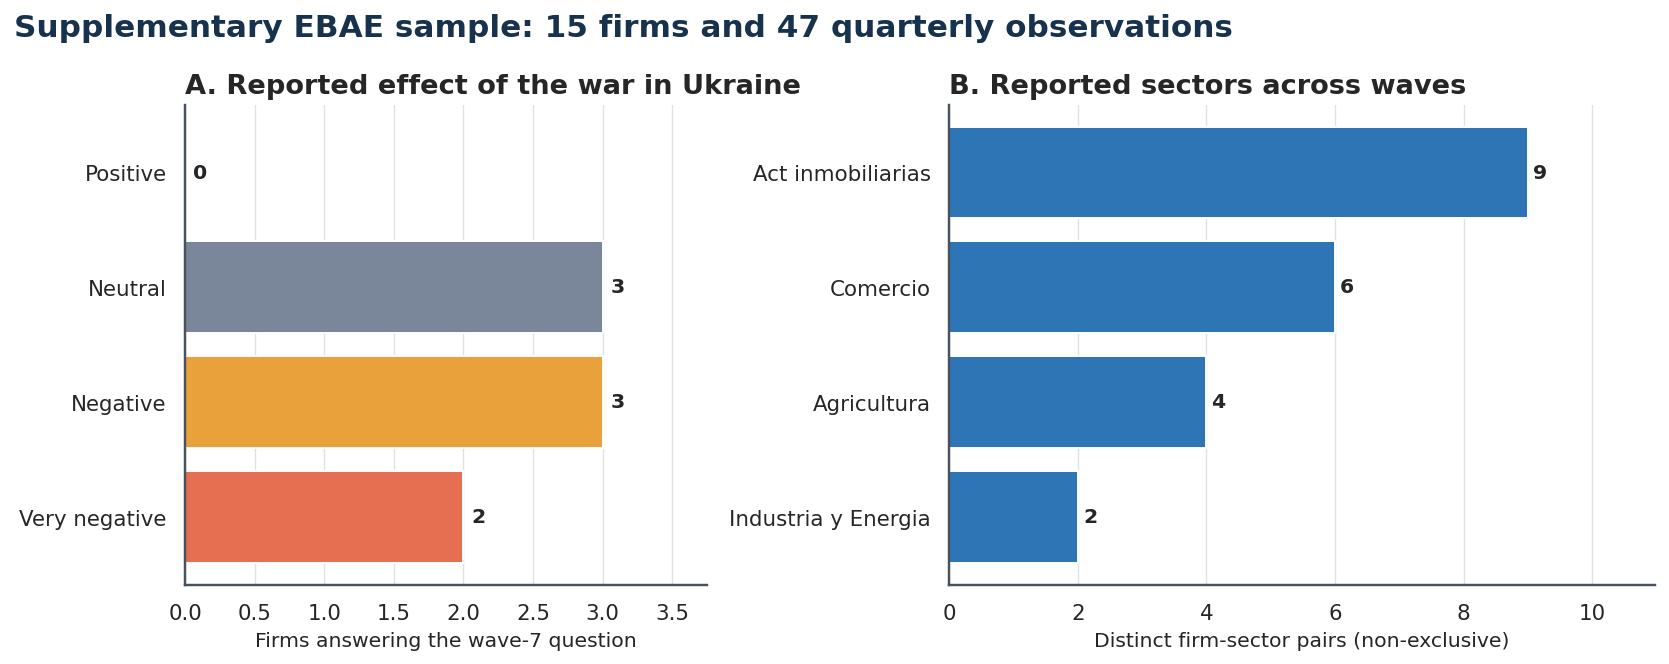

In [18]:
ebae = pd.read_csv(EBAE_SAMPLE, sep=';', dtype=str, keep_default_na=False)
impact_labels = {'1': 'Very negative', '2': 'Negative', '3': 'Neutral', '4': 'Positive'}
impact = ebae.loc[ebae['impguerra_sum'].ne(''), ['codigo', 'impguerra_sum']].copy()
impact['response'] = impact['impguerra_sum'].map(impact_labels)
impact_counts = impact['response'].value_counts().reindex(impact_labels.values(), fill_value=0)
sector_counts = ebae.groupby('rama12')['codigo'].nunique().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={'width_ratios': [0.85, 1.15]})
response_colours = [ORANGE, '#E9A23B', GREY, TEAL]
axes[0].barh(impact_counts.index, impact_counts.values, color=response_colours)
axes[0].set_xlabel('Firms answering the wave-7 question')
axes[0].set_title('A. Reported effect of the war in Ukraine', loc='left')
for y, value in enumerate(impact_counts.values):
    axes[0].text(value + 0.06, y, str(int(value)), va='center', fontweight='bold')
axes[0].set_xlim(0, max(impact_counts.max(), 1) * 1.25)
axes[0].grid(axis='y', visible=False)

axes[1].barh(sector_counts.index, sector_counts.values, color=BLUE)
axes[1].set_xlabel('Distinct firm-sector pairs (non-exclusive)')
axes[1].set_title('B. Reported sectors across waves', loc='left')
for y, value in enumerate(sector_counts.values):
    axes[1].text(value + 0.08, y, str(int(value)), va='center', fontweight='bold')
axes[1].set_xlim(0, max(sector_counts.max(), 1) * 1.22)
axes[1].grid(axis='y', visible=False)

fig.suptitle(f'Supplementary EBAE sample: {ebae.codigo.nunique()} firms and {len(ebae)} quarterly observations', x=0.01, ha='left', fontsize=16, fontweight='bold', color=NAVY)
finish_figure(fig)


**Reader takeaway:** In the latest displayed wave, five of eight responding firms report a negative or very negative effect of the war in Ukraine, while three report a neutral effect. The 15-firm sample adds practical business context but remains supplementary to the procurement portfolio. Sector counts are non-exclusive because some sample IDs appear in more than one sector across waves.


## 19. Inspect the dashboard evidence

The dashboard reads the same retained scored portfolio and event crosswalk already reconciled above. The two screenshots are shown separately so their labels remain readable.


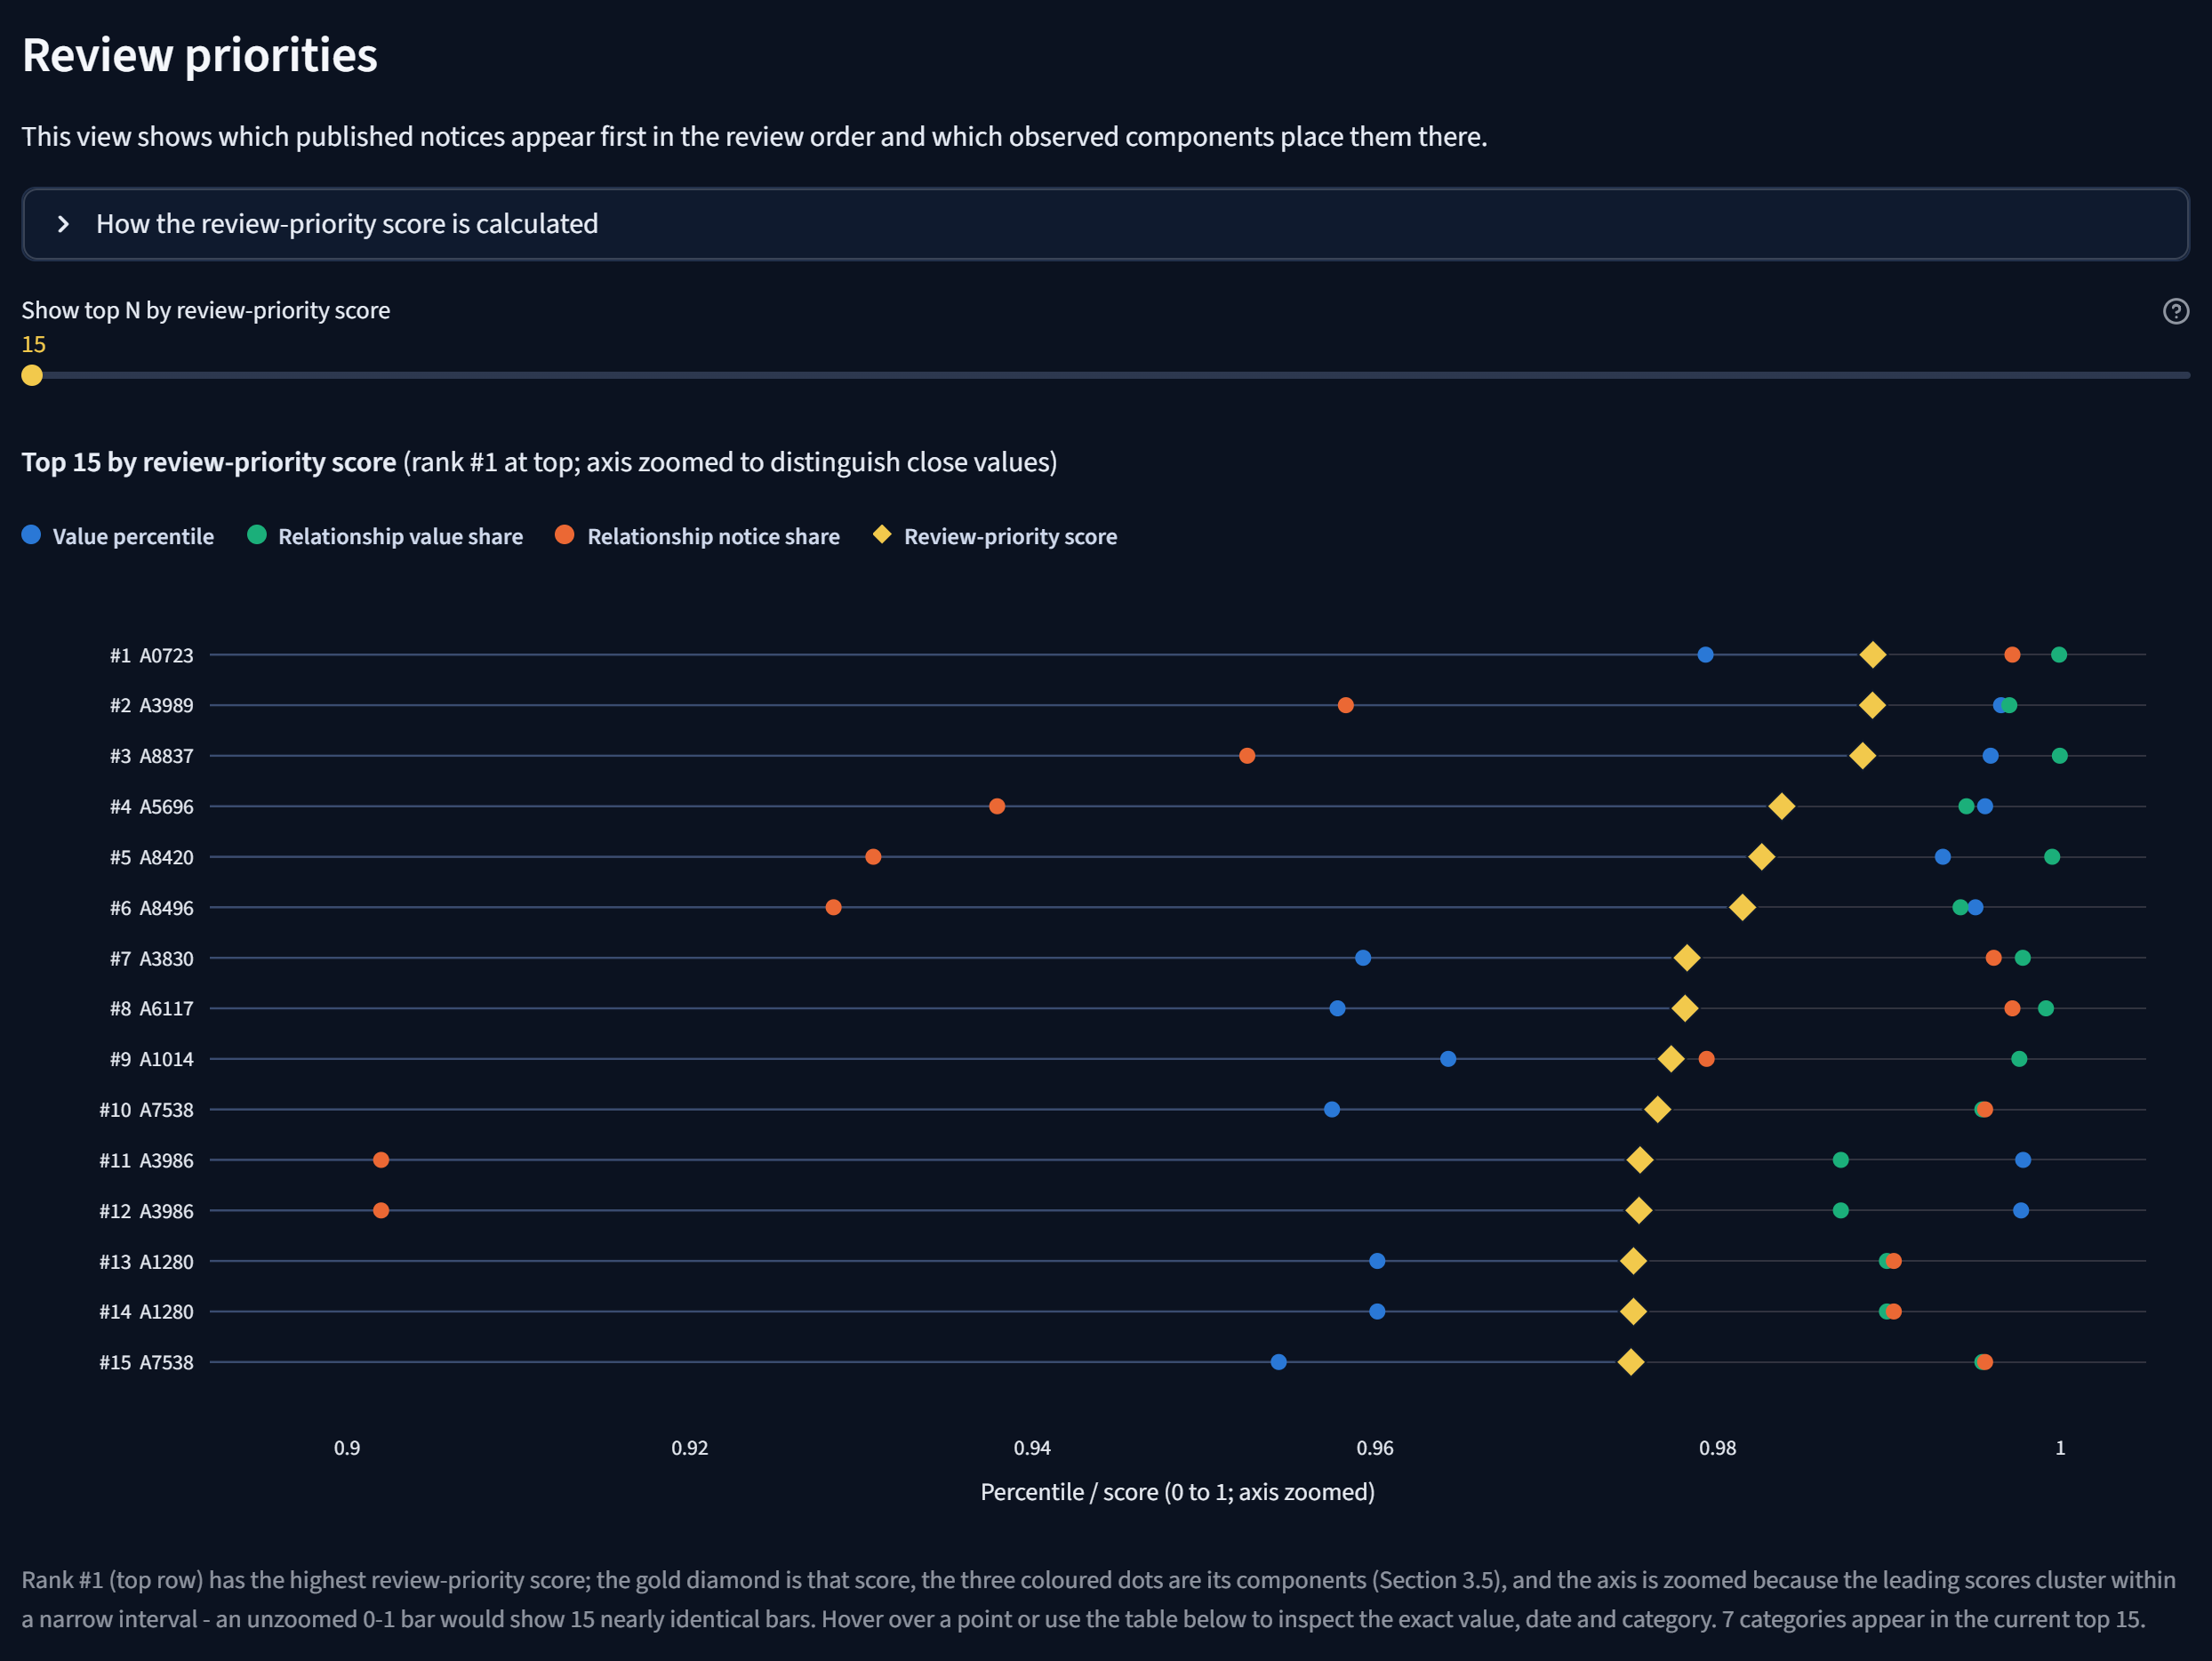

In [19]:
dashboard_inputs = {
    'Scored portfolio': FROZEN_SCORED_WITH_EVENTS,
    'Official event registry': EVENTS,
    'Event-notice crosswalk': FROZEN_MATCHES,
    'Supplementary EBAE sample': EBAE_SAMPLE,
}
missing_dashboard_inputs = [name for name, path in dashboard_inputs.items() if not path.exists()]
assert not missing_dashboard_inputs, f'Missing dashboard inputs: {missing_dashboard_inputs}'

display(NotebookImage(filename=str(FIGURES / 'figure_A1_dashboard_priority.png'), width=1100))


**Reader takeaway:** The dashboard places the final score beside its three components, so a reviewer can see both the order and the reason for that order before opening an individual notice.


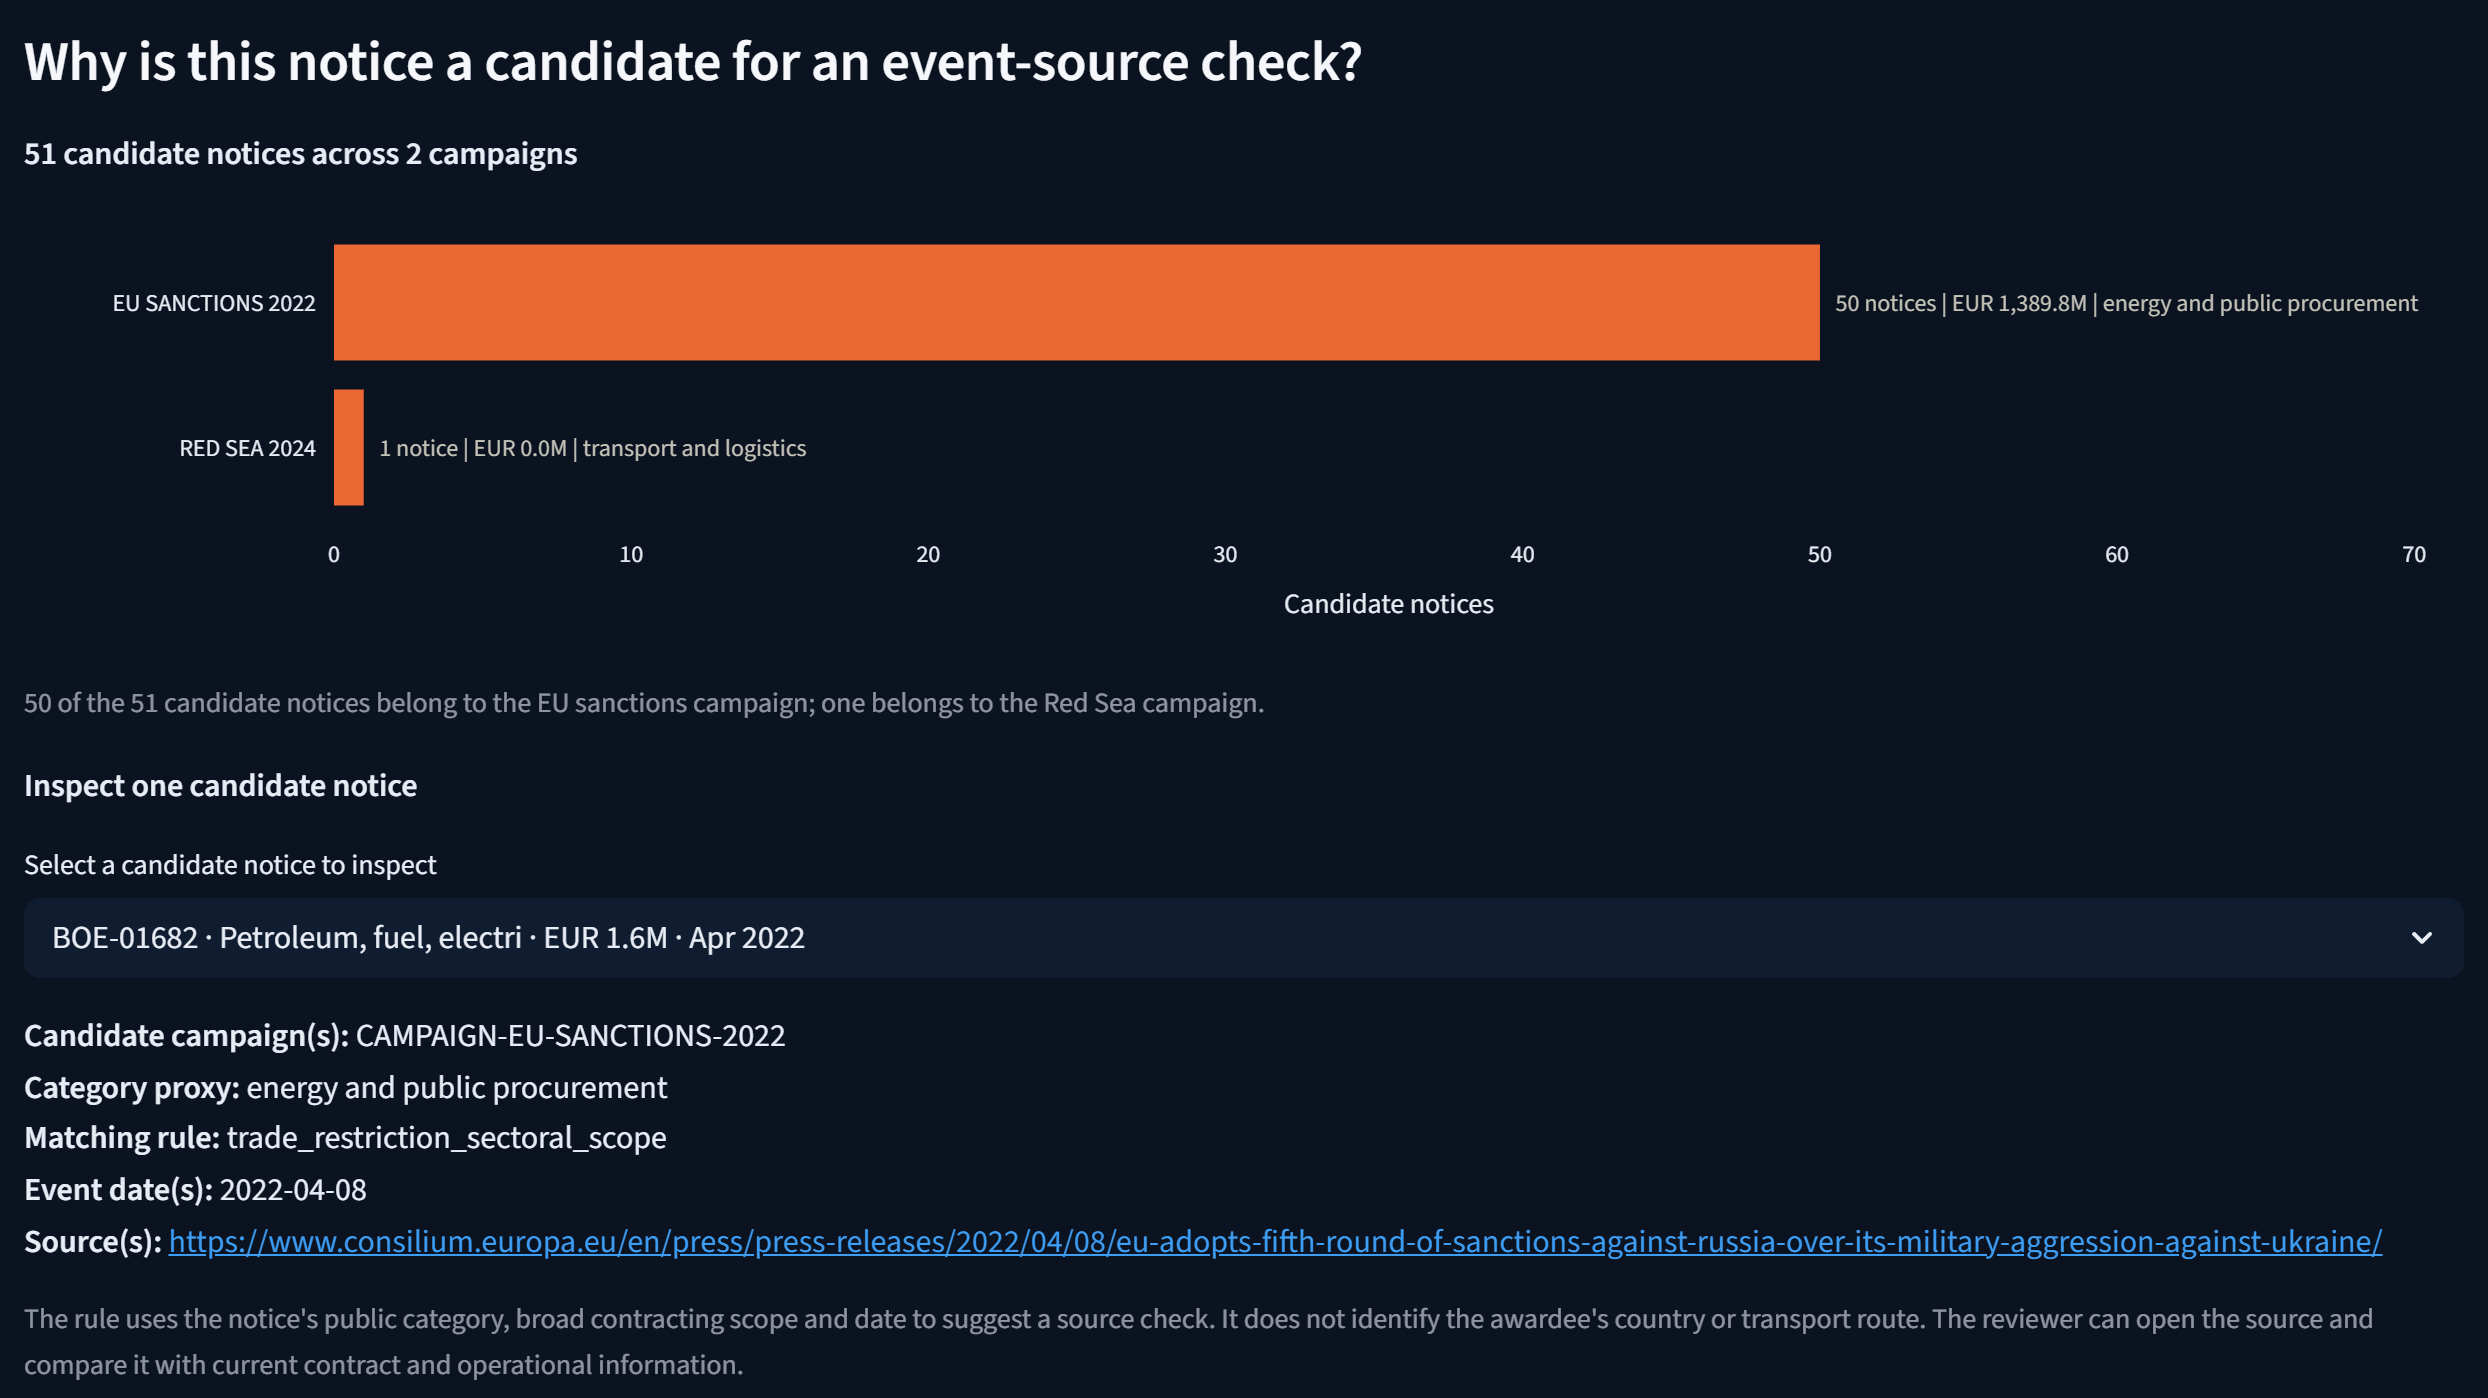

In [20]:
display(NotebookImage(filename=str(FIGURES / 'figure_A2_dashboard_event_context.png'), width=1100))


**Reader takeaway:** The event view shows the campaign, category and date rule, matched notice and official source link together. This creates a clear source-checking path before a procurement decision is considered.


## 20. Launch the dashboard

This final cell starts Streamlit with the same Python environment as the notebook, waits until the local address responds, prints the full link and opens the default browser. The frozen dashboard works without API keys; credentials are needed only for an optional live refresh.


In [21]:
DASHBOARD_PORTS = tuple(range(8501, 8511))
DASHBOARD_SCRIPT = (ROOT / 'dashboard' / 'dashboard.py').resolve()
dashboard_process = None

def streamlit_is_healthy(port):
    from urllib.request import urlopen
    try:
        with urlopen(f'http://127.0.0.1:{port}/_stcore/health', timeout=2) as response:
            return response.status == 200 and response.read().strip() == b'ok'
    except OSError:
        return False

def dashboard_responds(port, host='127.0.0.1', timeout=0.6):
    try:
        with socket.create_connection((host, port), timeout=timeout):
            return True
    except OSError:
        return False

def listener_command_line(port):
    if os.name != 'nt':
        return ''
    powershell_query = (
        f'$connection = Get-NetTCPConnection -LocalPort {port} -State Listen '
        '-ErrorAction SilentlyContinue | Select-Object -First 1; '
        'if ($connection) { (Get-CimInstance Win32_Process '
        '-Filter "ProcessId=$($connection.OwningProcess)").CommandLine }'
    )
    result = subprocess.run(
        ['powershell', '-NoProfile', '-Command', powershell_query],
        capture_output=True,
        text=True,
        timeout=8,
        check=False,
    )
    return result.stdout.strip()

def current_dashboard_responds(port):
    if not streamlit_is_healthy(port):
        return False
    if dashboard_process is not None and dashboard_process.poll() is None and port == DASHBOARD_PORT:
        return True
    if os.name != 'nt':
        return False
    return str(DASHBOARD_SCRIPT).lower() in listener_command_line(port).lower()

DASHBOARD_PORT = next(
    (port for port in DASHBOARD_PORTS if current_dashboard_responds(port)),
    None,
)
if DASHBOARD_PORT is None:
    DASHBOARD_PORT = next(
        (port for port in DASHBOARD_PORTS if not dashboard_responds(port)),
        None,
    )
if DASHBOARD_PORT is None:
    raise RuntimeError('Ports 8501 to 8510 are in use. Close one local service and rerun this cell.')

DASHBOARD_URL = f'http://localhost:{DASHBOARD_PORT}'
if not current_dashboard_responds(DASHBOARD_PORT):
    creation_flags = subprocess.CREATE_NO_WINDOW if os.name == 'nt' else 0
    dashboard_process = subprocess.Popen(
        [
            sys.executable,
            '-m',
            'streamlit',
            'run',
            str(DASHBOARD_SCRIPT),
            '--server.port',
            str(DASHBOARD_PORT),
            '--server.headless',
            'true',
        ],
        cwd=ROOT,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
        creationflags=creation_flags,
    )
    for _ in range(30):
        if current_dashboard_responds(DASHBOARD_PORT):
            break
        time.sleep(1)

if not current_dashboard_responds(DASHBOARD_PORT):
    raise RuntimeError(f'The current dashboard did not become ready at {DASHBOARD_URL}')

display(HTML(
    f"<div style='border-left:5px solid #1B998B;padding:12px 16px;background:#F2FAF8;'>"
    f"<b>Current package dashboard ready.</b> <a href='{DASHBOARD_URL}' target='_blank'>"
    f"Open {DASHBOARD_URL}</a></div>"
))
print(f'Dashboard link (copy and paste into Microsoft Edge): {DASHBOARD_URL}')
if os.environ.get('PGER_SKIP_BROWSER_OPEN') != '1':
    webbrowser.open_new_tab(DASHBOARD_URL)


Dashboard link (copy and paste into Microsoft Edge): http://localhost:8502


**Reader takeaway:** The launcher selects an available local port and verifies that the running dashboard belongs to this package before reporting its full link. The frozen portfolio and event views work without live API credentials; credentials are needed only for an optional refresh.


## 21. Final takeaways

The analysis turns a documented public-procurement release into a transparent review workflow. It preserves the route from each of the 24,765 cleaned notices to its source, shows how three observed components create the structural order, and makes the strongest portfolio concentration visible rather than hiding it inside a model.

The official event layer answers a different question: which notices deserve an additional source check when a dated external event and a procurement category meet the declared crosswalk rules? Keeping this layer separate from the structural score makes both decisions easier to explain and change.

The resulting dashboard gives a reviewer two practical starting points: inspect the highest structural priorities or examine notices connected to official event context. A later company pilot can add authorised purchasing information and test how these two queues support real procurement work.
